#Mount Drive


# New Section

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q timm torch torchvision scikit-learn pandas matplotlib seaborn pillow

Mounted at /content/drive


#Import Libraries

In [ ]:
import os
import shutil
import random
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageChops, ImageEnhance
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms

import timm

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

#Seed & Device


In [ ]:
 SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


#Set Paths

In [ ]:
RAW_DATASET_DIR = "/content/drive/MyDrive/autismemotion"

PROJECT_DIR     = "/content/drive/MyDrive/autismemotion_project2"

SPLIT_DIR       = os.path.join(PROJECT_DIR, "split_70_15_15")
SPLIT_TRAIN_DIR = os.path.join(SPLIT_DIR,   "train")
SPLIT_VAL_DIR   = os.path.join(SPLIT_DIR,   "val")
SPLIT_TEST_DIR  = os.path.join(SPLIT_DIR,   "test")

AUG_DIR         = os.path.join(PROJECT_DIR, "augmented_400_100_100_v2")
AUG_TRAIN_DIR   = os.path.join(AUG_DIR,     "train")
AUG_VAL_DIR     = os.path.join(AUG_DIR,     "val")
AUG_TEST_DIR    = os.path.join(AUG_DIR,     "test")

RESULTS_DIR     = os.path.join(PROJECT_DIR, "results")

os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Raw dataset    :", RAW_DATASET_DIR)
print("Project folder :", PROJECT_DIR)
print("Split dir      :", SPLIT_DIR)
print("Aug dir        :", AUG_DIR)
print("Results dir    :", RESULTS_DIR)

Raw dataset    : /content/drive/MyDrive/autismemotion
Project folder : /content/drive/MyDrive/autismemotion_project2
Split dir      : /content/drive/MyDrive/autismemotion_project2/split_70_15_15
Aug dir        : /content/drive/MyDrive/autismemotion_project2/augmented_400_100_100_v2
Results dir    : /content/drive/MyDrive/autismemotion_project2/results


#70/15/15 Split

In [ ]:
def normalize_class_name(class_name):
    class_name = class_name.strip().lower()
    if class_name == "nautral":
        return "natural"
    if class_name == "neutral":
        return "natural"
    return class_name


def get_image_files(folder):
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]


def clear_folder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


clear_folder(SPLIT_DIR)

os.makedirs(SPLIT_TRAIN_DIR, exist_ok=True)
os.makedirs(SPLIT_VAL_DIR,   exist_ok=True)
os.makedirs(SPLIT_TEST_DIR,  exist_ok=True)

train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

class_folders = [
    f for f in os.listdir(RAW_DATASET_DIR)
    if os.path.isdir(os.path.join(RAW_DATASET_DIR, f))
]

print("Detected classes:", class_folders)

for class_name in class_folders:
    original_class_path = os.path.join(RAW_DATASET_DIR, class_name)
    clean_class_name    = normalize_class_name(class_name)

    train_class_path = os.path.join(SPLIT_TRAIN_DIR, clean_class_name)
    val_class_path   = os.path.join(SPLIT_VAL_DIR,   clean_class_name)
    test_class_path  = os.path.join(SPLIT_TEST_DIR,  clean_class_name)

    os.makedirs(train_class_path, exist_ok=True)
    os.makedirs(val_class_path,   exist_ok=True)
    os.makedirs(test_class_path,  exist_ok=True)

    image_files  = get_image_files(original_class_path)
    random.shuffle(image_files)

    total_images = len(image_files)
    train_count  = int(total_images * train_ratio)
    val_count    = int(total_images * val_ratio)

    train_files  = image_files[:train_count]
    val_files    = image_files[train_count:train_count + val_count]
    test_files   = image_files[train_count + val_count:]

    for idx, src in enumerate(train_files):
        ext = os.path.splitext(src)[1].lower()
        dst = os.path.join(train_class_path, f"{clean_class_name}_train_{idx+1}{ext}")
        shutil.copy2(src, dst)

    for idx, src in enumerate(val_files):
        ext = os.path.splitext(src)[1].lower()
        dst = os.path.join(val_class_path, f"{clean_class_name}_val_{idx+1}{ext}")
        shutil.copy2(src, dst)

    for idx, src in enumerate(test_files):
        ext = os.path.splitext(src)[1].lower()
        dst = os.path.join(test_class_path, f"{clean_class_name}_test_{idx+1}{ext}")
        shutil.copy2(src, dst)

    print(
        f"{clean_class_name}: "
        f"total={total_images}, "
        f"train={len(train_files)}, "
        f"val={len(val_files)}, "
        f"test={len(test_files)}"
    )

print("\n70-15-15 split completed.")
print("Split train folder     :", SPLIT_TRAIN_DIR)
print("Split validation folder:", SPLIT_VAL_DIR)
print("Split test folder      :", SPLIT_TEST_DIR)

Detected classes: ['sadness', 'surprise', 'Natural', 'anger', 'fear', 'joy']
sadness: total=237, train=165, val=35, test=37
surprise: total=237, train=165, val=35, test=37
natural: total=240, train=168, val=36, test=36
anger: total=240, train=168, val=36, test=36
fear: total=236, train=165, val=35, test=36
joy: total=235, train=164, val=35, test=36

70-15-15 split completed.
Split train folder     : /content/drive/MyDrive/autismemotion_project2/split_70_15_15/train
Split validation folder: /content/drive/MyDrive/autismemotion_project2/split_70_15_15/val
Split test folder      : /content/drive/MyDrive/autismemotion_project2/split_70_15_15/test


#Augmentation

In [ ]:
def get_image_files(folder):
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(valid_ext)
    ]


def clear_folder(path):
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)


def random_shift_image(img, max_shift_ratio=0.10):
    img         = img.convert("RGB")
    width, height = img.size
    max_dx      = int(width  * max_shift_ratio)
    max_dy      = int(height * max_shift_ratio)
    dx          = random.randint(-max_dx, max_dx)
    dy          = random.randint(-max_dy, max_dy)
    shifted_img = ImageChops.offset(img, dx, dy)
    if dx > 0:
        shifted_img.paste((0, 0, 0), (0, 0, dx, height))
    elif dx < 0:
        shifted_img.paste((0, 0, 0), (width + dx, 0, width, height))
    if dy > 0:
        shifted_img.paste((0, 0, 0), (0, 0, width, dy))
    elif dy < 0:
        shifted_img.paste((0, 0, 0), (0, height + dy, width, height))
    return shifted_img


def zoom_image_nearest(img, zoom_factor=0.1):
    """
    Zoom in by zoom_factor, fill borders with nearest pixel (replication).
    zoom_factor=0.1 means 10% zoom.
    """
    img           = img.convert("RGB")
    width, height = img.size
    crop_w        = int(width  / (1 + zoom_factor))
    crop_h        = int(height / (1 + zoom_factor))
    left          = (width  - crop_w) // 2
    top           = (height - crop_h) // 2
    right         = left + crop_w
    bottom        = top  + crop_h
    img_cropped   = img.crop((left, top, right, bottom))
    img_zoomed    = img_cropped.resize((width, height), Image.NEAREST)
    return img_zoomed


def rotate_image_nearest(img, max_angle=15):
    """
    Rotate by random angle up to max_angle degrees.
    Fill empty borders using nearest neighbor (expand=False).
    """
    img   = img.convert("RGB")
    angle = random.uniform(-max_angle, max_angle)
    img   = img.rotate(angle, resample=Image.NEAREST, expand=False)
    return img


def adjust_brightness(img, low=0.6, high=1.4):
    """
    Randomly adjust brightness between low and high factor.
    """
    img      = img.convert("RGB")
    factor   = random.uniform(low, high)
    enhancer = ImageEnhance.Brightness(img)
    img      = enhancer.enhance(factor)
    return img


# ============================================================
# Augmentation types — combined REMOVED
# ============================================================

ALL_AUGMENTATIONS = [
    "horizontal_flip",
    "vertical_flip",
    "height_width_shift",
    "edge_detection",
    "zoom",
    "rotation",
    "brightness"
]


def apply_augmentation(img, aug_type):
    img = img.convert("RGB")

    if aug_type == "horizontal_flip":
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    elif aug_type == "vertical_flip":
        img = img.transpose(Image.FLIP_TOP_BOTTOM)

    elif aug_type == "height_width_shift":
        img = random_shift_image(img, max_shift_ratio=0.10)

    elif aug_type == "edge_detection":
        img = img.filter(ImageFilter.FIND_EDGES)

    elif aug_type == "zoom":
        img = zoom_image_nearest(img, zoom_factor=0.1)

    elif aug_type == "rotation":
        img = rotate_image_nearest(img, max_angle=15)

    elif aug_type == "brightness":
        img = adjust_brightness(img, low=0.6, high=1.4)

    return img


def get_next_augmentation(image_path, used_augs_tracker):
    """
    Always picks an augmentation type not yet used for this image.
    Resets tracker only when all 7 types are exhausted.
    This guarantees no same augmentation twice in a row per image.
    """
    already_used = used_augs_tracker[image_path]
    remaining    = [a for a in ALL_AUGMENTATIONS if a not in already_used]

    if not remaining:
        used_augs_tracker[image_path] = set()
        remaining = ALL_AUGMENTATIONS[:]

    chosen = random.choice(remaining)
    used_augs_tracker[image_path].add(chosen)

    return chosen


def augment_class_to_target(
    source_class_dir,
    target_class_dir,
    target_count,
    image_size=(256, 256)
):
    os.makedirs(target_class_dir, exist_ok=True)

    source_images = get_image_files(source_class_dir)

    if len(source_images) == 0:
        print("No images found in:", source_class_dir)
        return

    used_augs_tracker = defaultdict(set)
    copied            = 0

    # First copy all originals
    for src in source_images:
        if copied >= target_count:
            break
        try:
            img = Image.open(src).convert("RGB")
            img = img.resize(image_size, Image.NEAREST)
            dst = os.path.join(target_class_dir, f"original_{copied+1}.jpg")
            img.save(dst, quality=95)
            copied += 1
        except Exception as e:
            print("Skipped:", src, e)

    current_count = copied
    aug_index     = 1

    # Then augment until target count reached
    while current_count < target_count:
        src = random.choice(source_images)
        try:
            aug_type = get_next_augmentation(src, used_augs_tracker)
            img      = Image.open(src).convert("RGB")
            img      = img.resize(image_size, Image.NEAREST)
            img      = apply_augmentation(img, aug_type)
            dst      = os.path.join(
                target_class_dir,
                f"aug_{aug_index}_{aug_type}.jpg"
            )
            img.save(dst, quality=95)
            current_count += 1
            aug_index     += 1
        except Exception as e:
            print("Augmentation skipped:", src, e)

    print(f"{os.path.basename(target_class_dir)}: {current_count} images created")


# ============================================================
# Verify paths
# ============================================================

print("Source SPLIT_TRAIN_DIR :", SPLIT_TRAIN_DIR)
print("Source SPLIT_VAL_DIR   :", SPLIT_VAL_DIR)
print("Source SPLIT_TEST_DIR  :", SPLIT_TEST_DIR)
print("Target AUG_TRAIN_DIR   :", AUG_TRAIN_DIR)
print("Target AUG_VAL_DIR     :", AUG_VAL_DIR)
print("Target AUG_TEST_DIR    :", AUG_TEST_DIR)


# ============================================================
# Clear and recreate augmented folders
# ============================================================

clear_folder(AUG_DIR)

os.makedirs(AUG_TRAIN_DIR, exist_ok=True)
os.makedirs(AUG_VAL_DIR,   exist_ok=True)
os.makedirs(AUG_TEST_DIR,  exist_ok=True)

print("\nAugmented folders created inside:", AUG_DIR)


# ============================================================
# Target counts
# ============================================================

TRAIN_TARGET_PER_CLASS = 400
VAL_TARGET_PER_CLASS   = 100
TEST_TARGET_PER_CLASS  = 100


# ============================================================
# Run augmentation for all classes
# ============================================================

classes = sorted([
    f for f in os.listdir(SPLIT_TRAIN_DIR)
    if os.path.isdir(os.path.join(SPLIT_TRAIN_DIR, f))
])

print("\nClasses detected:", classes)

for cls in classes:
    print(f"\nProcessing class: {cls}")

    augment_class_to_target(
        source_class_dir=os.path.join(SPLIT_TRAIN_DIR, cls),
        target_class_dir=os.path.join(AUG_TRAIN_DIR,   cls),
        target_count=TRAIN_TARGET_PER_CLASS,
        image_size=(256, 256)
    )

    augment_class_to_target(
        source_class_dir=os.path.join(SPLIT_VAL_DIR,   cls),
        target_class_dir=os.path.join(AUG_VAL_DIR,     cls),
        target_count=VAL_TARGET_PER_CLASS,
        image_size=(256, 256)
    )

    augment_class_to_target(
        source_class_dir=os.path.join(SPLIT_TEST_DIR,  cls),
        target_class_dir=os.path.join(AUG_TEST_DIR,    cls),
        target_count=TEST_TARGET_PER_CLASS,
        image_size=(256, 256)
    )

print("\nAugmentation completed.")


# ============================================================
# Verify final image counts
# ============================================================

print("\nFinal image counts:")
for split_name, split_dir in [
    ("Train", AUG_TRAIN_DIR),
    ("Val",   AUG_VAL_DIR),
    ("Test",  AUG_TEST_DIR)
]:
    print(f"\n{split_name}:")
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            count = len(get_image_files(cls_path))
            print(f"  {cls}: {count} images")

Source SPLIT_TRAIN_DIR : /content/drive/MyDrive/autismemotion_project2/split_70_15_15/train
Source SPLIT_VAL_DIR   : /content/drive/MyDrive/autismemotion_project2/split_70_15_15/val
Source SPLIT_TEST_DIR  : /content/drive/MyDrive/autismemotion_project2/split_70_15_15/test
Target AUG_TRAIN_DIR   : /content/drive/MyDrive/autismemotion_project2/augmented_400_100_100_v2/train
Target AUG_VAL_DIR     : /content/drive/MyDrive/autismemotion_project2/augmented_400_100_100_v2/val
Target AUG_TEST_DIR    : /content/drive/MyDrive/autismemotion_project2/augmented_400_100_100_v2/test

Augmented folders created inside: /content/drive/MyDrive/autismemotion_project2/augmented_400_100_100_v2

Classes detected: ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']

Processing class: anger
anger: 400 images created
anger: 100 images created
anger: 100 images created

Processing class: fear
fear: 400 images created
fear: 100 images created
fear: 100 images created

Processing class: joy
joy: 400 images

#Runtime Transform

In [ ]:
IMG_SIZE   = 224
BATCH_SIZE = 16
NUM_WORKERS = 2
EPOCHS     = 100
LR         = 1e-4

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.95, 1.0)   # zoom 0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transform ready.")
print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}, LR={LR}")

Transform ready.
IMG_SIZE=224, BATCH_SIZE=16, EPOCHS=100, LR=0.0001


#EfficientNet-B0 (Batch 16)

Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000

Training EfficientNet-B0 | Batch Size: 16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 54.86it/s]


Epoch 1/30 | Train Loss: 1.9482 | Train Acc: 0.4303 | Val Loss: 1.0131 | Val Acc: 0.7167 | LR: 0.00009055 | Time: 5.6s


...

Epoch 28/30 | Train Loss: 0.3275 | Train Acc: 0.9797 | Val Loss: 0.3178 | Val Acc: 0.9867 | LR: 0.00002803 | Time: 4.6s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 50.59it/s]


Epoch 29/30 | Train Loss: 0.3258 | Train Acc: 0.9790 | Val Loss: 0.3031 | Val Acc: 0.9917 | LR: 0.00002140 | Time: 4.3s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 50.24it/s]


Epoch 30/30 | Train Loss: 0.3221 | Train Acc: 0.9797 | Val Loss: 0.3122 | Val Acc: 0.9850 | LR: 0.00001550 | Time: 4.3s


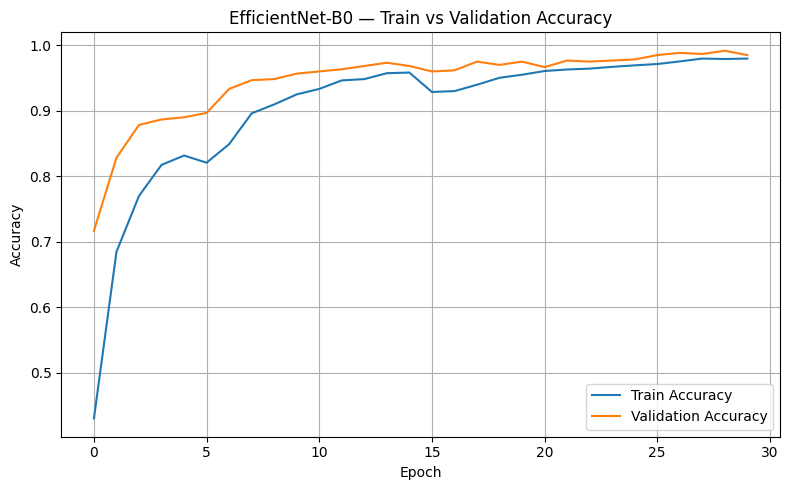

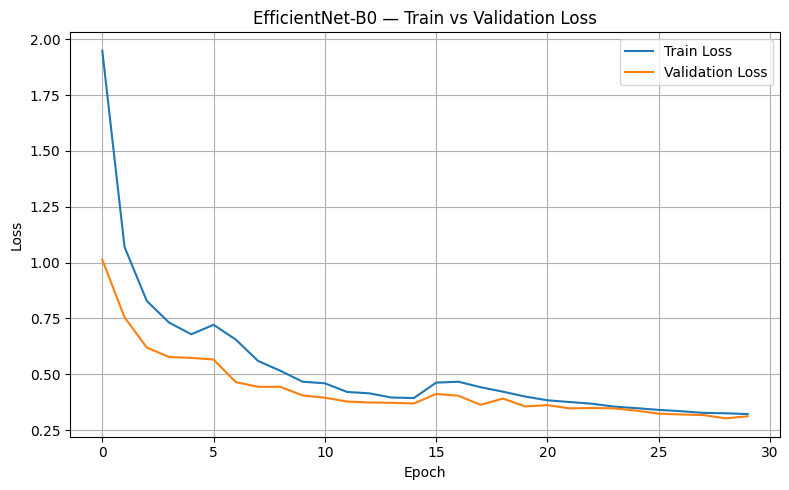


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:01<00:00, 23.86it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6909    0.7600    0.7238       100
        fear     0.7797    0.9200    0.8440       100
         joy     0.8073    0.8800    0.8421       100
     natural     0.8190    0.8600    0.8390       100
     sadness     0.6167    0.3700    0.4625       100
    surprise     0.7449    0.7300    0.7374       100

    accuracy                         0.7533       600
   macro avg     0.7431    0.7533    0.7415       600
weighted avg     0.7431    0.7533    0.7415       600



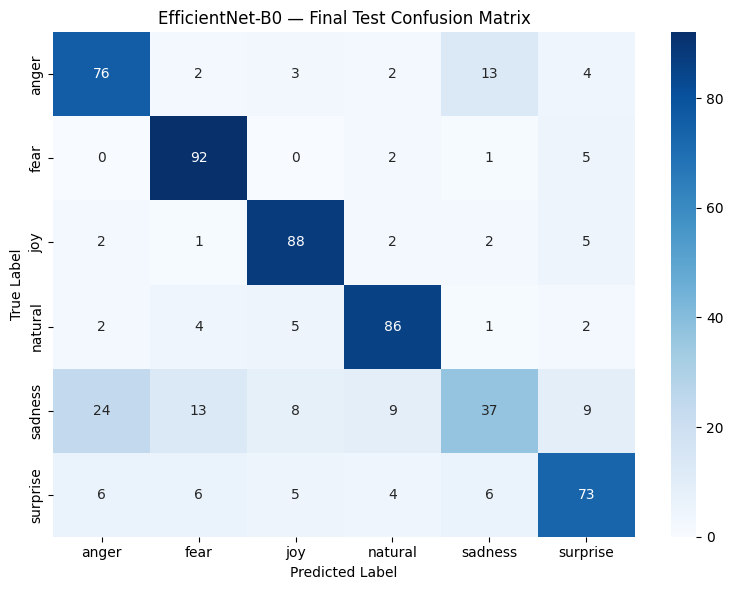


EfficientNet-B0 Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,efficientnet_b0,16,0.9797,0.7533,0.7431,0.7533,0.7415,0.7431,0.7533,0.7415



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/efficientnet_b0


In [ ]:
import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Settings
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Datasets — using already defined transform
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")
if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# ============================================================
# Build Model
# ============================================================

def build_efficientnet_b0(num_classes):
    return timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)

# ============================================================
# Training Function
# ============================================================

def train_efficientnet_b0(epochs=EPOCHS, lr=LR, model_folder_name="efficientnet_b0"):
    print("\n" + "=" * 90)
    print("Training EfficientNet-B0 | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = build_efficientnet_b0(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss   = val_loss_sum / val_total
        val_acc    = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("EfficientNet-B0 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("EfficientNet-B0 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("EfficientNet-B0 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "efficientnet_b0_result_summary.csv"), index=False)
    print("\nEfficientNet-B0 Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model

efficientnet_b0_result, efficientnet_b0_model = train_efficientnet_b0(
    epochs=EPOCHS, lr=LR, model_folder_name="efficientnet_b0"
)

#Swin-Tiny (Batch 16)


Training Swin-Tiny | Batch Size: 16


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 48.94it/s]


Epoch 1/30 | Train Loss: 1.3877 | Train Acc: 0.4680 | Val Loss: 0.7941 | Val Acc: 0.7783 | LR: 0.00009055 | Time: 6.4s


Epoch 2/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 49.00it/s]


...

Epoch 28/30 | Train Loss: 0.3021 | Train Acc: 0.9723 | Val Loss: 0.2776 | Val Acc: 0.9833 | LR: 0.00002803 | Time: 6.9s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 51.28it/s]


Epoch 29/30 | Train Loss: 0.2951 | Train Acc: 0.9750 | Val Loss: 0.2816 | Val Acc: 0.9833 | LR: 0.00002140 | Time: 5.9s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 52.93it/s]


Epoch 30/30 | Train Loss: 0.2884 | Train Acc: 0.9790 | Val Loss: 0.2727 | Val Acc: 0.9867 | LR: 0.00001550 | Time: 6.1s


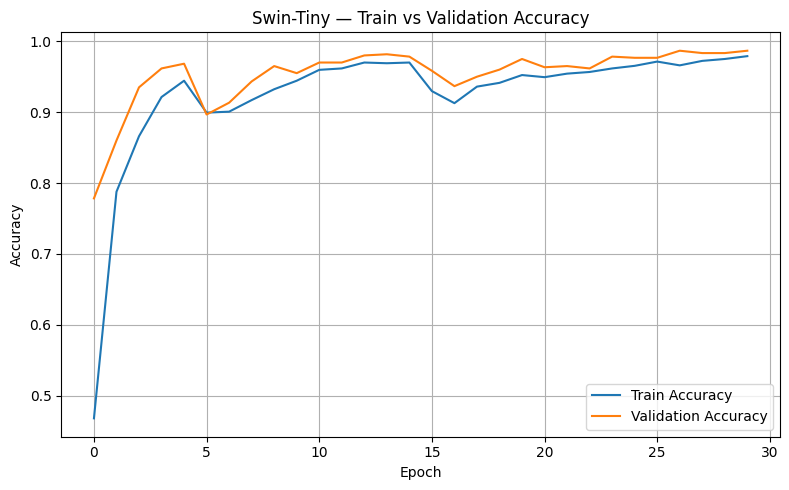

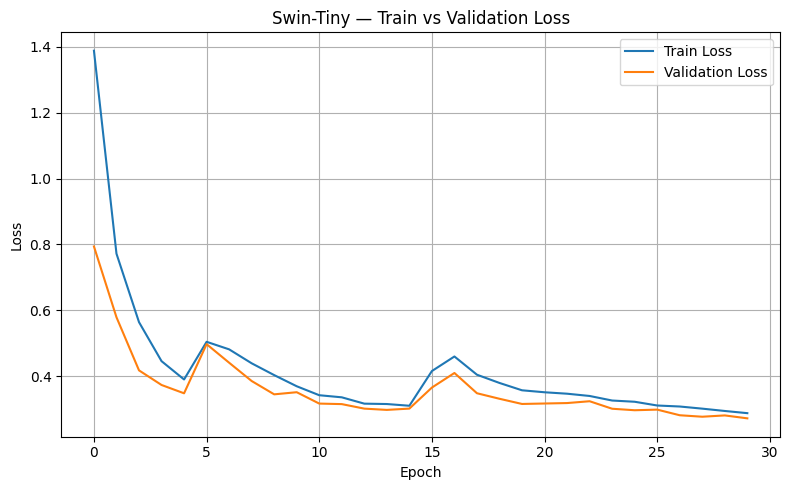


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 51.43it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7143    0.8000    0.7547       100
        fear     0.8261    0.9500    0.8837       100
         joy     0.9038    0.9400    0.9216       100
     natural     0.8378    0.9300    0.8815       100
     sadness     0.7377    0.4500    0.5590       100
    surprise     0.8763    0.8500    0.8629       100

    accuracy                         0.8200       600
   macro avg     0.8160    0.8200    0.8106       600
weighted avg     0.8160    0.8200    0.8106       600



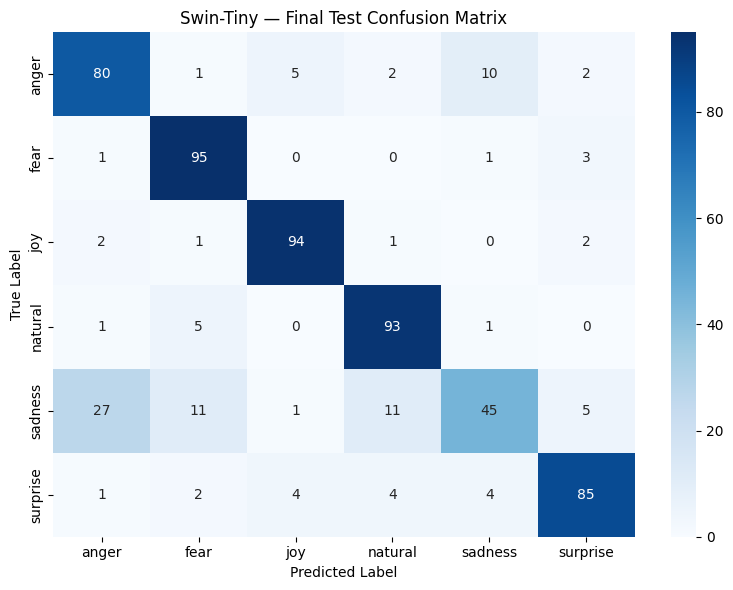


Swin-Tiny Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,swin_tiny,16,0.979,0.82,0.816,0.82,0.8106,0.816,0.82,0.8106



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/swin_tiny


In [ ]:
def build_swin_tiny(num_classes):
    return timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=num_classes)

def train_swin_tiny(epochs=EPOCHS, lr=LR, model_folder_name="swin_tiny"):
    print("\n" + "=" * 90)
    print("Training Swin-Tiny | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = build_swin_tiny(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("Swin-Tiny — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("Swin-Tiny — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("Swin-Tiny — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "swin_tiny_result_summary.csv"), index=False)
    print("\nSwin-Tiny Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model

swin_tiny_result, swin_tiny_model = train_swin_tiny(
    epochs=EPOCHS, lr=LR, model_folder_name="swin_tiny"
)

#InceptionV3 (Batch 16)


Training InceptionV3 | Batch Size: 16


model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 40.08it/s]


Epoch 1/30 | Train Loss: 1.3853 | Train Acc: 0.5397 | Val Loss: 0.7720 | Val Acc: 0.7800 | LR: 0.00009055 | Time: 7.5s


Epoch 2/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 40.37it/s]


...

Epoch 28/30 | Train Loss: 0.2897 | Train Acc: 0.9853 | Val Loss: 0.2738 | Val Acc: 0.9967 | LR: 0.00002803 | Time: 6.2s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:01<00:00, 37.97it/s]


Epoch 29/30 | Train Loss: 0.2901 | Train Acc: 0.9840 | Val Loss: 0.2726 | Val Acc: 0.9950 | LR: 0.00002140 | Time: 6.2s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 38.16it/s]


Epoch 30/30 | Train Loss: 0.2867 | Train Acc: 0.9870 | Val Loss: 0.2778 | Val Acc: 0.9883 | LR: 0.00001550 | Time: 6.9s


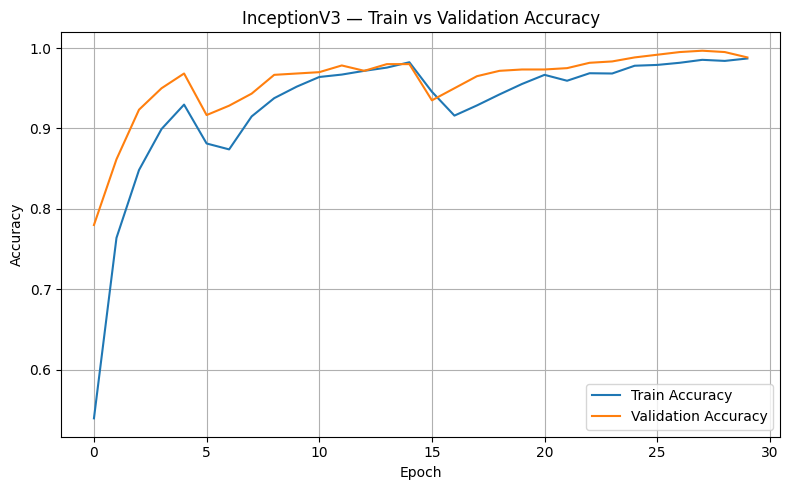

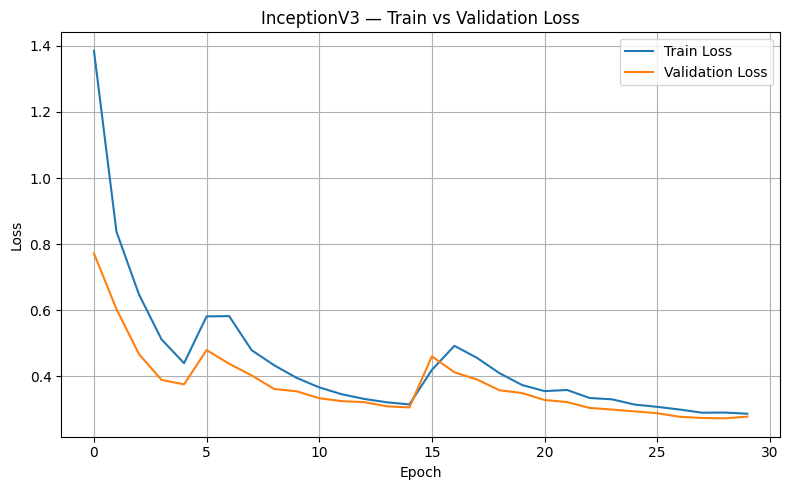


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 38.56it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6975    0.8300    0.7580       100
        fear     0.7826    0.9000    0.8372       100
         joy     0.9216    0.9400    0.9307       100
     natural     0.7870    0.8500    0.8173       100
     sadness     0.6491    0.3700    0.4713       100
    surprise     0.8283    0.8200    0.8241       100

    accuracy                         0.7850       600
   macro avg     0.7777    0.7850    0.7731       600
weighted avg     0.7777    0.7850    0.7731       600



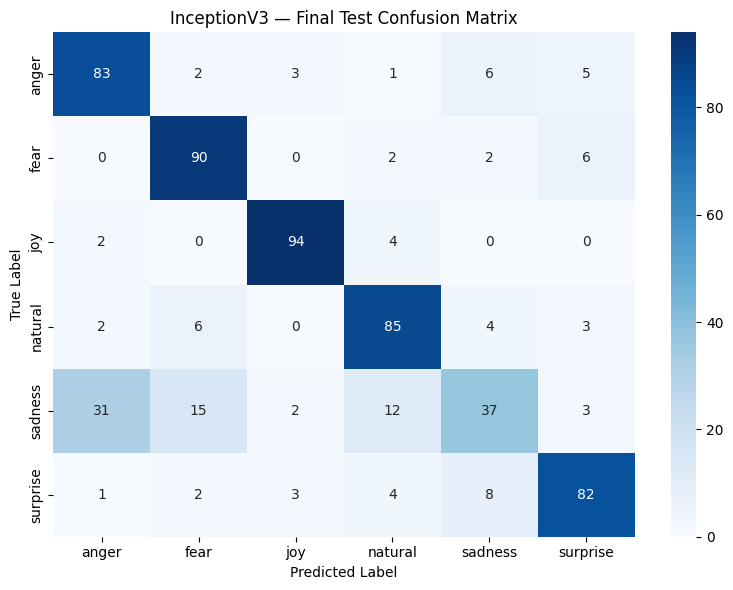


InceptionV3 Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,inception_v3,16,0.987,0.785,0.7777,0.785,0.7731,0.7777,0.785,0.7731



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/inception_v3


In [ ]:
def build_inception_v3(num_classes):
    return timm.create_model("inception_v3", pretrained=True, num_classes=num_classes)

# InceptionV3 needs 299x299 — separate transform
inception_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1),
    transforms.RandomResizedCrop(299, scale=(0.95, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

inception_train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=inception_transform)
inception_val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=inception_transform)
inception_test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=inception_transform)
inception_combined      = ConcatDataset([inception_train_dataset, inception_val_dataset])

inception_train_loader  = DataLoader(inception_combined,      batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
inception_val_loader    = DataLoader(inception_val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
inception_test_loader   = DataLoader(inception_test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

def train_inception_v3(epochs=EPOCHS, lr=LR, model_folder_name="inception_v3"):
    print("\n" + "=" * 90)
    print("Training InceptionV3 | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = build_inception_v3(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(inception_train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(inception_val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                if isinstance(outputs, tuple):
                    outputs = outputs[0]
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("InceptionV3 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("InceptionV3 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(inception_test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            if isinstance(outputs, tuple):
                outputs = outputs[0]
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("InceptionV3 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "inception_v3_result_summary.csv"), index=False)
    print("\nInceptionV3 Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model

inception_v3_result, inception_v3_model = train_inception_v3(
    epochs=EPOCHS, lr=LR, model_folder_name="inception_v3"
)

#ViT-Base/16 (Batch 16)


Training ViT-Base/16 | Batch Size: 16


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 48.22it/s]


Epoch 1/30 | Train Loss: 1.8607 | Train Acc: 0.1783 | Val Loss: 1.8661 | Val Acc: 0.1817 | LR: 0.00009055 | Time: 12.1s


Epoch 2/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 45.79it/s]


...

Epoch 28/30 | Train Loss: 0.3180 | Train Acc: 0.9643 | Val Loss: 0.3234 | Val Acc: 0.9667 | LR: 0.00002803 | Time: 9.4s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 49.62it/s]


Epoch 29/30 | Train Loss: 0.3160 | Train Acc: 0.9653 | Val Loss: 0.3093 | Val Acc: 0.9683 | LR: 0.00002140 | Time: 9.5s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 50.17it/s]


Epoch 30/30 | Train Loss: 0.3025 | Train Acc: 0.9713 | Val Loss: 0.2988 | Val Acc: 0.9783 | LR: 0.00001550 | Time: 9.8s


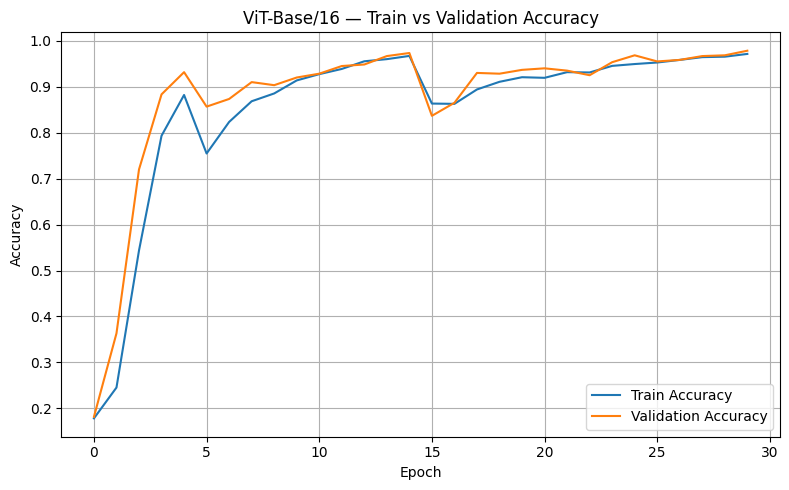

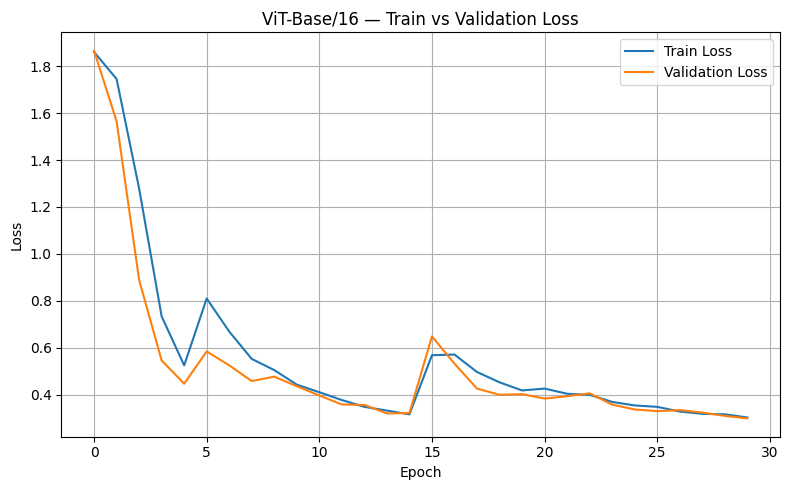


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 49.96it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7477    0.8000    0.7729       100
        fear     0.8381    0.8800    0.8585       100
         joy     0.8208    0.8700    0.8447       100
     natural     0.8396    0.8900    0.8641       100
     sadness     0.6806    0.4900    0.5698       100
    surprise     0.8173    0.8500    0.8333       100

    accuracy                         0.7967       600
   macro avg     0.7907    0.7967    0.7906       600
weighted avg     0.7907    0.7967    0.7906       600



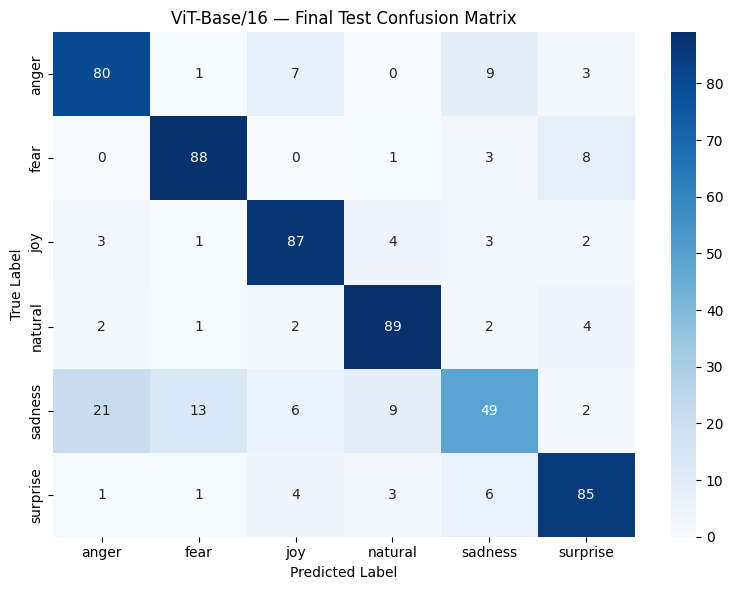


ViT-Base/16 Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,vit_base_patch16_224,16,0.9713,0.7967,0.7907,0.7967,0.7906,0.7907,0.7967,0.7906



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/vit_base_patch16_224


In [ ]:
def build_vit(num_classes):
    return timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=num_classes)

def train_vit(epochs=EPOCHS, lr=LR, model_folder_name="vit_base_patch16_224"):
    print("\n" + "=" * 90)
    print("Training ViT-Base/16 | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = build_vit(num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("ViT-Base/16 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("ViT-Base/16 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("ViT-Base/16 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "vit_result_summary.csv"), index=False)
    print("\nViT-Base/16 Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model

vit_result, vit_model = train_vit(
    epochs=EPOCHS, lr=LR, model_folder_name="vit_base_patch16_224"
)

#Hybrid EfficientNet-B0 + Swin-Tiny


Training Hybrid: EfficientNet-B0 + Swin-Tiny | Batch Size: 16


Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 49.59it/s]


Epoch 1/30 | Train Loss: 1.5176 | Train Acc: 0.4067 | Val Loss: 1.0330 | Val Acc: 0.6567 | LR: 0.00009055 | Time: 8.4s


Epoch 2/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 48.49it/s]


Epoch 2/30 | Train Loss: 0.9181 | Train Acc: 0.7257 | Val Loss: 0.5716 | Val Acc: 0.8550 | LR: 0.00006580 | Time: 8.3s


...

Epoch 28/30 | Train Loss: 0.3103 | Train Acc: 0.9720 | Val Loss: 0.2872 | Val Acc: 0.9800 | LR: 0.00002803 | Time: 8.4s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:02<00:00, 17.39it/s]


Epoch 29/30 | Train Loss: 0.3033 | Train Acc: 0.9753 | Val Loss: 0.2815 | Val Acc: 0.9867 | LR: 0.00002140 | Time: 9.8s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 50.48it/s]


Epoch 30/30 | Train Loss: 0.3001 | Train Acc: 0.9773 | Val Loss: 0.2772 | Val Acc: 0.9883 | LR: 0.00001550 | Time: 8.4s


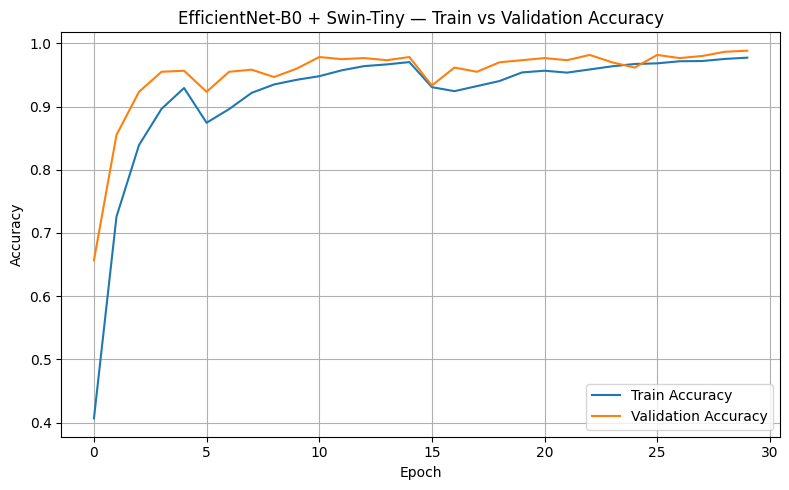

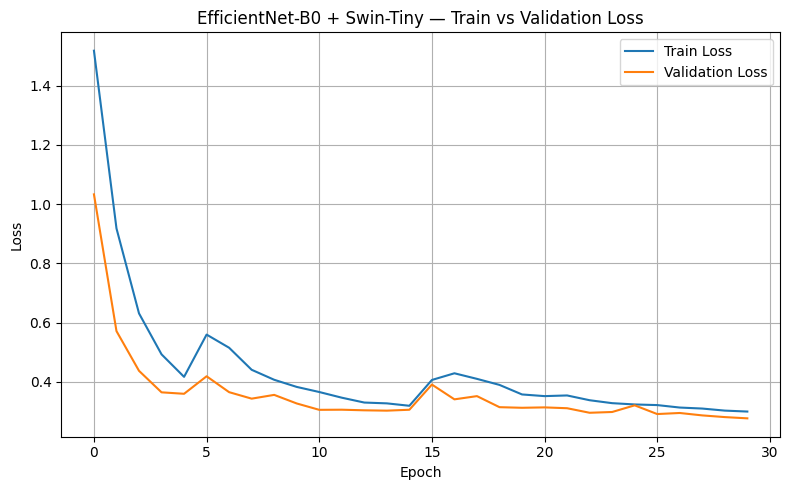


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 51.83it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6695    0.7900    0.7248       100
        fear     0.8411    0.9000    0.8696       100
         joy     0.9320    0.9600    0.9458       100
     natural     0.8519    0.9200    0.8846       100
     sadness     0.6833    0.4100    0.5125       100
    surprise     0.7981    0.8300    0.8137       100

    accuracy                         0.8017       600
   macro avg     0.7960    0.8017    0.7918       600
weighted avg     0.7960    0.8017    0.7918       600



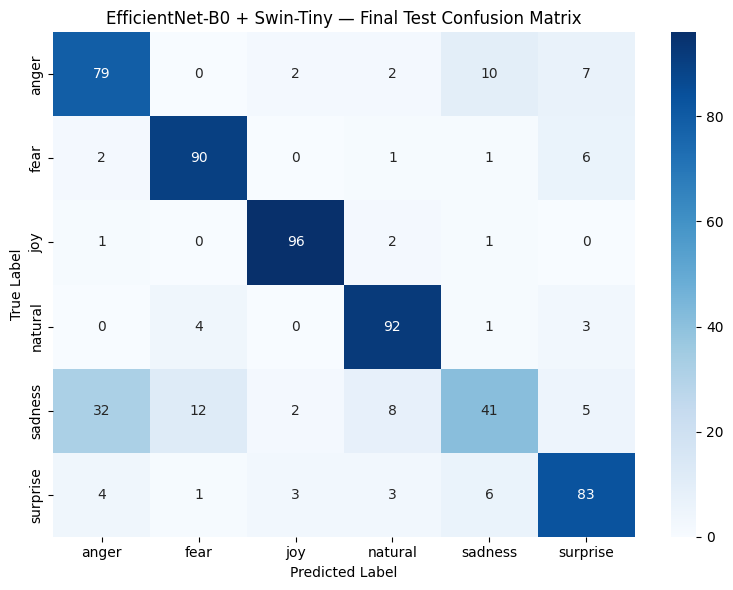


Hybrid EfficientNet-B0 + Swin-Tiny Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,crossattn_fusion_efficientnet_b0_swin_tiny,16,0.9773,0.8017,0.796,0.8017,0.7918,0.796,0.8017,0.7918



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/crossattn_fusion_efficientnet_b0_swin_tiny


In [ ]:
class CrossAttentionFusion(nn.Module):
    def __init__(self, embed_dim, num_heads=8, dropout=0.1):
        super(CrossAttentionFusion, self).__init__()
        self.cross_attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm            = nn.LayerNorm(embed_dim)

    def forward(self, cnn_feat, trans_feat):
        attention_output, _ = self.cross_attention(query=cnn_feat, key=trans_feat, value=trans_feat)
        return self.norm(attention_output + cnn_feat)


class EfficientNetSwinFusion(nn.Module):
    def __init__(self, num_classes, embed_dim=768, num_heads=8):
        super(EfficientNetSwinFusion, self).__init__()
        self.cnn_backbone           = timm.create_model("efficientnet_b0", pretrained=True, features_only=True)
        cnn_channels                = self.cnn_backbone.feature_info.channels()[-1]
        self.transformer            = timm.create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=0)
        transformer_dim             = self.transformer.num_features
        self.cnn_projection         = nn.Linear(cnn_channels,    embed_dim)
        self.transformer_projection = nn.Linear(transformer_dim, embed_dim)
        self.cross_attention        = CrossAttentionFusion(embed_dim=embed_dim, num_heads=num_heads)
        self.classifier             = nn.Sequential(
            nn.Linear(embed_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_features   = self.cnn_backbone(x)[-1]
        B, C, H, W     = cnn_features.shape
        cnn_features   = self.cnn_projection(cnn_features.flatten(2).transpose(1, 2))
        trans_features = self.transformer.forward_features(x)
        if len(trans_features.shape) == 4:
            B2, H2, W2, C2 = trans_features.shape
            trans_features  = trans_features.view(B2, H2 * W2, C2)
        trans_features = self.transformer_projection(trans_features)
        fused          = self.cross_attention(cnn_features, trans_features).mean(dim=1)
        return self.classifier(fused)


def train_efficientnet_swin_fusion(epochs=EPOCHS, lr=LR, model_folder_name="crossattn_fusion_efficientnet_b0_swin_tiny"):
    print("\n" + "=" * 90)
    print("Training Hybrid: EfficientNet-B0 + Swin-Tiny | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = EfficientNetSwinFusion(num_classes=num_classes, embed_dim=768, num_heads=8).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("EfficientNet-B0 + Swin-Tiny — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("EfficientNet-B0 + Swin-Tiny — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("EfficientNet-B0 + Swin-Tiny — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "crossattn_efficientnet_swin_result_summary.csv"), index=False)
    print("\nHybrid EfficientNet-B0 + Swin-Tiny Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model

crossattn_swin_result, crossattn_swin_model = train_efficientnet_swin_fusion(
    epochs=EPOCHS, lr=LR, model_folder_name="crossattn_fusion_efficientnet_b0_swin_tiny"
)

#Hybrid EfficientNet-B0 + ViT (Batch 16):


Training Hybrid: EfficientNet-B0 + ViT-Base/16 | Batch Size: 16


Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 43.76it/s]


Epoch 1/30 | Train Loss: 1.6110 | Train Acc: 0.3513 | Val Loss: 1.0577 | Val Acc: 0.6917 | LR: 0.00009055 | Time: 12.3s


Epoch 2/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 44.26it/s]


Epoch 2/30 | Train Loss: 0.9977 | Train Acc: 0.6890 | Val Loss: 0.6366 | Val Acc: 0.8283 | LR: 0.00006580 | Time: 12.2s


...

Epoch 28/30 | Train Loss: 0.3093 | Train Acc: 0.9753 | Val Loss: 0.2828 | Val Acc: 0.9850 | LR: 0.00002803 | Time: 13.5s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 43.15it/s]


Epoch 29/30 | Train Loss: 0.3146 | Train Acc: 0.9723 | Val Loss: 0.2852 | Val Acc: 0.9850 | LR: 0.00002140 | Time: 13.1s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 43.36it/s]


Epoch 30/30 | Train Loss: 0.3078 | Train Acc: 0.9747 | Val Loss: 0.2830 | Val Acc: 0.9867 | LR: 0.00001550 | Time: 12.1s


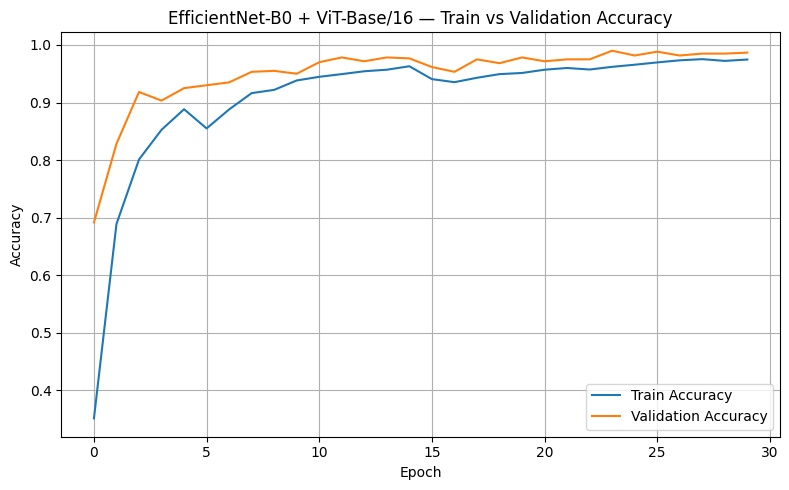

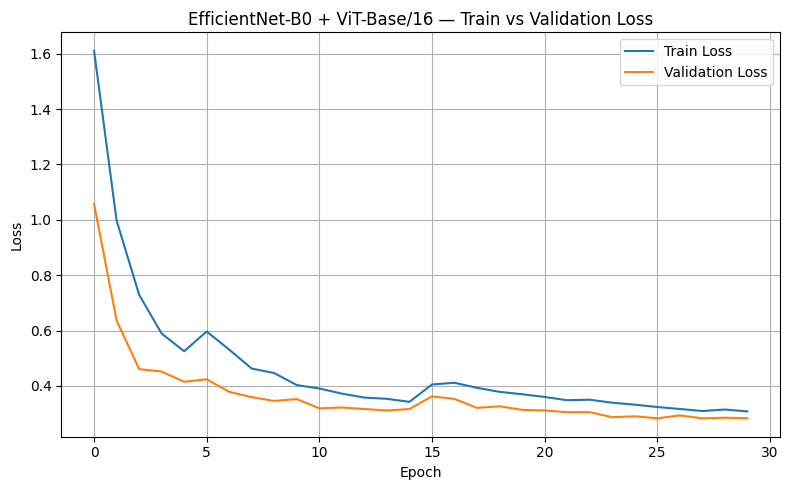


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 42.58it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6870    0.7900    0.7349       100
        fear     0.8482    0.9500    0.8962       100
         joy     0.9109    0.9200    0.9154       100
     natural     0.8365    0.8700    0.8529       100
     sadness     0.6538    0.5100    0.5730       100
    surprise     0.8667    0.7800    0.8211       100

    accuracy                         0.8033       600
   macro avg     0.8005    0.8033    0.7989       600
weighted avg     0.8005    0.8033    0.7989       600



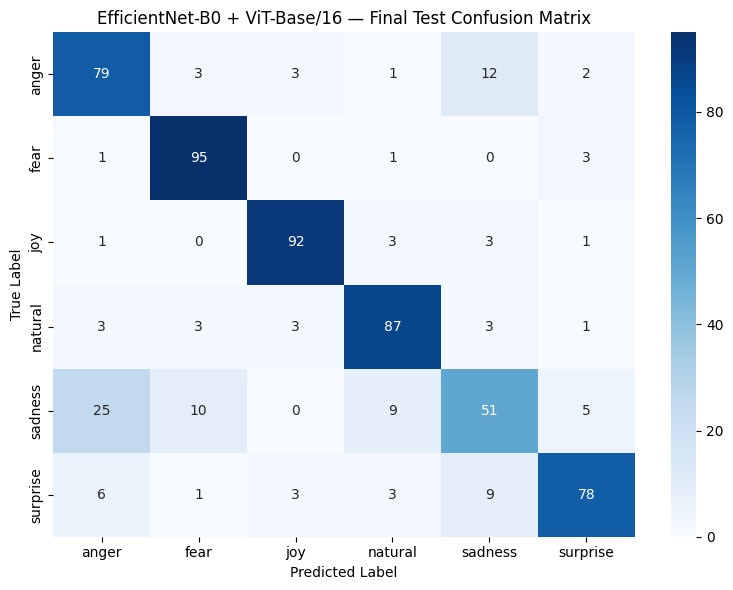


Hybrid EfficientNet-B0 + ViT-Base/16 Final Result:


,model,batch_size,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,crossattn_fusion_efficientnet_b0_vit,16,0.9753,0.8033,0.8005,0.8033,0.7989,0.8005,0.8033,0.7989



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/crossattn_fusion_efficientnet_b0_vit


In [ ]:
class EfficientNetViTFusion(nn.Module):
    def __init__(self, num_classes, embed_dim=768, num_heads=8):
        super(EfficientNetViTFusion, self).__init__()
        self.cnn_backbone           = timm.create_model("efficientnet_b0", pretrained=True, features_only=True)
        cnn_channels                = self.cnn_backbone.feature_info.channels()[-1]
        self.transformer            = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
        transformer_dim             = self.transformer.num_features
        self.cnn_projection         = nn.Linear(cnn_channels,    embed_dim)
        self.transformer_projection = nn.Linear(transformer_dim, embed_dim)
        self.cross_attention        = CrossAttentionFusion(embed_dim=embed_dim, num_heads=num_heads)
        self.classifier             = nn.Sequential(
            nn.Linear(embed_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        cnn_features   = self.cnn_backbone(x)[-1]
        B, C, H, W     = cnn_features.shape
        cnn_features   = self.cnn_projection(cnn_features.flatten(2).transpose(1, 2))
        trans_features = self.transformer.forward_features(x)
        trans_features = trans_features[:, 1:, :]
        trans_features = self.transformer_projection(trans_features)
        fused          = self.cross_attention(cnn_features, trans_features).mean(dim=1)
        return self.classifier(fused)


def train_efficientnet_vit_fusion(epochs=EPOCHS, lr=LR, model_folder_name="crossattn_fusion_efficientnet_b0_vit"):
    print("\n" + "=" * 90)
    print("Training Hybrid: EfficientNet-B0 + ViT-Base/16 | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = EfficientNetViTFusion(num_classes=num_classes, embed_dim=768, num_heads=8).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("EfficientNet-B0 + ViT-Base/16 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("EfficientNet-B0 + ViT-Base/16 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("EfficientNet-B0 + ViT-Base/16 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "crossattn_efficientnet_vit_result_summary.csv"), index=False)
    print("\nHybrid EfficientNet-B0 + ViT-Base/16 Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model

crossattn_vit_result, crossattn_vit_model = train_efficientnet_vit_fusion(
    epochs=EPOCHS, lr=LR, model_folder_name="crossattn_fusion_efficientnet_b0_vit"
)

# Modified Swin-Tiny

In [ ]:
# # ============================================================
# # Modified Swin-Tiny
# # Changes:
# #   Stage 2 (Block index 1) → Replaced with EfficientNet MBConv Block
# #   Stage 3 (Block index 2) → Added CBAM Attention after Swin Block
# #   Stage 1 and Stage 4     → Original Swin Blocks unchanged
# # ============================================================

# import os
# import time
# import copy
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import timm
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from torchvision import datasets
# from torch.utils.data import DataLoader, ConcatDataset
# from tqdm import tqdm
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# # ============================================================
# # Define RESULTS_DIR_B16 globally
# # ============================================================

# RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
# os.makedirs(RESULTS_DIR_B16, exist_ok=True)
# print("RESULTS_DIR_B16:", RESULTS_DIR_B16)


# # ============================================================
# # CHANGE 1 — CBAM Module (added after Stage 3)
# # Channel Attention + Spatial Attention combined
# # ============================================================

# class ChannelAttention(nn.Module):
#     def __init__(self, in_channels, reduction=16):
#         super(ChannelAttention, self).__init__()
#         self.avg_pool = nn.AdaptiveAvgPool2d(1)
#         self.max_pool = nn.AdaptiveMaxPool2d(1)
#         self.fc       = nn.Sequential(
#             nn.Linear(in_channels, in_channels // reduction, bias=False),
#             nn.ReLU(),
#             nn.Linear(in_channels // reduction, in_channels, bias=False)
#         )
#         self.sigmoid  = nn.Sigmoid()

#     def forward(self, x):
#         B, C, H, W = x.shape
#         avg_out    = self.fc(self.avg_pool(x).view(B, C))
#         max_out    = self.fc(self.max_pool(x).view(B, C))
#         out        = self.sigmoid(avg_out + max_out).view(B, C, 1, 1)
#         return x * out


# class SpatialAttention(nn.Module):
#     def __init__(self, kernel_size=7):
#         super(SpatialAttention, self).__init__()
#         self.conv    = nn.Conv2d(2, 1, kernel_size=kernel_size,
#                                  padding=kernel_size // 2, bias=False)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         avg_out    = torch.mean(x, dim=1, keepdim=True)
#         max_out, _ = torch.max(x,  dim=1, keepdim=True)
#         out        = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
#         return x * out


# class CBAM(nn.Module):
#     def __init__(self, in_channels, reduction=16, kernel_size=7):
#         super(CBAM, self).__init__()
#         self.channel_attention = ChannelAttention(in_channels, reduction)
#         self.spatial_attention = SpatialAttention(kernel_size)

#     def forward(self, x):
#         x = self.channel_attention(x)
#         x = self.spatial_attention(x)
#         return x


# # ============================================================
# # CHANGE 2 — EfficientNet MBConv Block (replaces Stage 2)
# # MBConv: Expand → Depthwise Conv → SE → Project
# # ============================================================

# class SqueezeExcitation(nn.Module):
#     def __init__(self, in_channels, reduction=4):
#         super(SqueezeExcitation, self).__init__()
#         reduced = max(1, in_channels // reduction)
#         self.se = nn.Sequential(
#             nn.AdaptiveAvgPool2d(1),
#             nn.Flatten(),
#             nn.Linear(in_channels, reduced, bias=False),
#             nn.SiLU(),
#             nn.Linear(reduced, in_channels, bias=False),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         scale = self.se(x).unsqueeze(-1).unsqueeze(-1)
#         return x * scale


# class MBConvBlock(nn.Module):
#     """
#     Mobile Inverted Bottleneck Conv Block from EfficientNet.
#     Replaces Stage 2 of Swin-Tiny.
#     expand_ratio=6 follows EfficientNet-B0 design.
#     """
#     def __init__(self, in_channels, out_channels, expand_ratio=6, stride=1):
#         super(MBConvBlock, self).__init__()
#         hidden_dim    = in_channels * expand_ratio
#         self.use_res  = (stride == 1 and in_channels == out_channels)
#         self.block    = nn.Sequential(
#             # Expand
#             nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
#             nn.BatchNorm2d(hidden_dim),
#             nn.SiLU(),
#             # Depthwise Conv
#             nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride,
#                       padding=1, groups=hidden_dim, bias=False),
#             nn.BatchNorm2d(hidden_dim),
#             nn.SiLU(),
#             # Squeeze-Excitation
#             SqueezeExcitation(hidden_dim),
#             # Project back
#             nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
#             nn.BatchNorm2d(out_channels)
#         )

#     def forward(self, x):
#         if self.use_res:
#             return x + self.block(x)
#         return self.block(x)


# # ============================================================
# # CHANGE 3 — Patch Merge layer
# # Simulates Swin patch merging between stages
# # Halves H,W and doubles channels
# # ============================================================

# class PatchMerge(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super(PatchMerge, self).__init__()
#         self.merge = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=2, stride=2, bias=False),
#             nn.BatchNorm2d(out_channels)
#         )

#     def forward(self, x):
#         return self.merge(x)


# # ============================================================
# # CHANGE 4 — Full Modified Swin-Tiny Model
# # Stage 1 (96ch)  → original Swin unchanged
# # Stage 2 (192ch) → REPLACED with MBConvBlock
# # Stage 3 (384ch) → original Swin + CBAM added after
# # Stage 4 (768ch) → original Swin unchanged
# # ============================================================

# class ModifiedSwinTiny(nn.Module):
#     def __init__(self, num_classes):
#         super(ModifiedSwinTiny, self).__init__()

#         # Pretrained Swin-Tiny backbone — all 4 stage outputs
#         self.swin_backbone = timm.create_model(
#             "swin_tiny_patch4_window7_224",
#             pretrained=True,
#             features_only=True,
#             out_indices=(0, 1, 2, 3)
#         )

#         # CHANGE: Patch merge from Stage 1 → Stage 2
#         # 96 channels → 192 channels, spatial 56x56 → 28x28
#         self.patch_merge_1_2 = PatchMerge(in_channels=96, out_channels=192)

#         # CHANGE: Stage 2 replaced with two MBConv blocks
#         # Input: 192ch, Output: 192ch
#         self.stage2_mbconv = nn.Sequential(
#             MBConvBlock(in_channels=192, out_channels=192, expand_ratio=6, stride=1),
#             MBConvBlock(in_channels=192, out_channels=192, expand_ratio=6, stride=1)
#         )

#         # CHANGE: CBAM added after Stage 3 Swin output
#         # Input: 384ch (Stage 3 output channels)
#         self.stage3_cbam = CBAM(in_channels=384, reduction=16, kernel_size=7)

#         # Classification head using Stage 4 output (768ch)
#         self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
#         self.classifier      = nn.Sequential(
#             nn.Flatten(),
#             nn.LayerNorm(768),
#             nn.Linear(768, 512),
#             nn.GELU(),
#             nn.Dropout(0.3),
#             nn.Linear(512, 256),
#             nn.GELU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         # Get all 4 stage outputs from Swin backbone
#         stage_outputs = self.swin_backbone(x)

#         # Stage 1 — [B, 56, 56, 96] — unchanged
#         s1     = stage_outputs[0]
#         s1_chw = s1.permute(0, 3, 1, 2).contiguous()        # [B, 96, 56, 56]

#         # CHANGE: Stage 2 — MBConv instead of Swin block
#         s2_in  = self.patch_merge_1_2(s1_chw)               # [B, 192, 28, 28]
#         s2     = self.stage2_mbconv(s2_in)                   # [B, 192, 28, 28]

#         # CHANGE: Stage 3 — Swin output + CBAM
#         s3_swin = stage_outputs[2]                           # [B, 14, 14, 384]
#         s3_chw  = s3_swin.permute(0, 3, 1, 2).contiguous() # [B, 384, 14, 14]
#         s3      = self.stage3_cbam(s3_chw)                  # [B, 384, 14, 14]

#         # Stage 4 — unchanged
#         s4     = stage_outputs[3]                            # [B, 7, 7, 768]
#         s4_chw = s4.permute(0, 3, 1, 2).contiguous()       # [B, 768, 7, 7]

#         # Classify from Stage 4
#         out    = self.global_avg_pool(s4_chw)               # [B, 768, 1, 1]
#         out    = self.classifier(out)                        # [B, num_classes]

#         return out


# # ============================================================
# # Training Function
# # ============================================================

# def train_modified_swin(epochs=EPOCHS, lr=LR, model_folder_name="modified_swin_tiny_mbconv_cbam"):
#     print("\n" + "=" * 90)
#     print("Training Modified Swin-Tiny")
#     print("  Stage 2 → Replaced with EfficientNet MBConv Block")
#     print("  Stage 3 → Swin Block + CBAM Attention added")
#     print("  Batch Size: 16")
#     print("=" * 90)

#     model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
#     os.makedirs(model_output_dir, exist_ok=True)

#     model     = ModifiedSwinTiny(num_classes=num_classes).to(device)
#     criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

#     # CHANGE: Per-layer learning rates
#     # Pretrained Swin backbone → lower LR to protect pretrained weights
#     # New MBConv, CBAM, classifier → higher LR to learn faster
#     pretrained_params = list(model.swin_backbone.parameters())
#     new_params        = (
#         list(model.patch_merge_1_2.parameters()) +
#         list(model.stage2_mbconv.parameters())   +
#         list(model.stage3_cbam.parameters())     +
#         list(model.classifier.parameters())
#     )

#     optimizer = optim.AdamW([
#         {"params": pretrained_params, "lr": lr * 0.1},  # 1e-5
#         {"params": new_params,        "lr": lr}          # 1e-4
#     ], weight_decay=1e-4)

#     scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
#         optimizer, T_0=5, T_mult=2, eta_min=1e-6
#     )

#     best_train_acc     = 0.0
#     best_model_weights = copy.deepcopy(model.state_dict())
#     history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

#     for epoch in range(epochs):
#         start_time = time.time()
#         model.train()
#         train_loss_sum, train_correct, train_total = 0.0, 0, 0

#         for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
#             images, labels  = images.to(device), labels.to(device)
#             optimizer.zero_grad()
#             outputs         = model(images)
#             loss            = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             _, predictions  = torch.max(outputs, 1)
#             train_loss_sum += loss.item() * images.size(0)
#             train_correct  += torch.sum(predictions == labels).item()
#             train_total    += labels.size(0)

#         train_loss = train_loss_sum / train_total
#         train_acc  = train_correct  / train_total

#         model.eval()
#         val_loss_sum, val_correct, val_total = 0.0, 0, 0

#         with torch.no_grad():
#             for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
#                 images, labels = images.to(device), labels.to(device)
#                 outputs        = model(images)
#                 loss           = criterion(outputs, labels)
#                 _, predictions = torch.max(outputs, 1)
#                 val_loss_sum  += loss.item() * images.size(0)
#                 val_correct   += torch.sum(predictions == labels).item()
#                 val_total     += labels.size(0)

#         val_loss = val_loss_sum / val_total
#         val_acc  = val_correct  / val_total
#         scheduler.step()

#         history["train_loss"].append(train_loss)
#         history["train_acc"].append(train_acc)
#         history["val_loss"].append(val_loss)
#         history["val_acc"].append(val_acc)

#         if train_acc > best_train_acc:
#             best_train_acc     = train_acc
#             best_model_weights = copy.deepcopy(model.state_dict())
#             torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

#         print(
#             f"Epoch {epoch+1}/{epochs} | "
#             f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
#             f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
#             f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
#             f"Time: {time.time()-start_time:.1f}s"
#         )

#     model.load_state_dict(best_model_weights)
#     pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

#     plt.figure(figsize=(8, 5))
#     plt.plot(history["train_acc"], label="Train Accuracy")
#     plt.plot(history["val_acc"],   label="Validation Accuracy")
#     plt.title("Modified Swin-Tiny — Train vs Validation Accuracy")
#     plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
#     plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

#     plt.figure(figsize=(8, 5))
#     plt.plot(history["train_loss"], label="Train Loss")
#     plt.plot(history["val_loss"],   label="Validation Loss")
#     plt.title("Modified Swin-Tiny — Train vs Validation Loss")
#     plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
#     plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

#     print("\n" + "=" * 90)
#     print("Final Testing on Test Set Only")
#     print("=" * 90)

#     model.eval()
#     test_y_true, test_y_pred = [], []

#     with torch.no_grad():
#         for images, labels in tqdm(test_loader, desc="Final Testing"):
#             images, labels = images.to(device), labels.to(device)
#             outputs        = model(images)
#             _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
#             test_y_true.extend(labels.cpu().numpy())
#             test_y_pred.extend(predictions.cpu().numpy())

#     print("\nFinal Test Classification Report:")
#     print(classification_report(
#         test_y_true, test_y_pred,
#         target_names=class_names,
#         digits=4,
#         zero_division=0
#     ))

#     cm = confusion_matrix(test_y_true, test_y_pred)
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names,
#                 yticklabels=class_names, cmap="Blues")
#     plt.title("Modified Swin-Tiny — Final Test Confusion Matrix")
#     plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
#     plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

#     report = classification_report(
#         test_y_true, test_y_pred,
#         target_names=class_names,
#         output_dict=True,
#         zero_division=0
#     )

#     pd.DataFrame(report).transpose().to_csv(
#         os.path.join(model_output_dir, "test_classification_report.csv")
#     )
#     pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
#         os.path.join(model_output_dir, "test_confusion_matrix.csv")
#     )

#     result = {
#         "model":                   model_folder_name,
#         "batch_size":              16,
#         "modification":            "Stage2=MBConv, Stage3=Swin+CBAM",
#         "best_train_accuracy":     round(best_train_acc, 4),
#         "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
#         "test_macro_precision":    round(report["macro avg"]["precision"], 4),
#         "test_macro_recall":       round(report["macro avg"]["recall"], 4),
#         "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
#         "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
#         "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
#         "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
#     }

#     result_df = pd.DataFrame([result])
#     result_df.to_csv(
#         os.path.join(model_output_dir, "modified_swin_result_summary.csv"),
#         index=False
#     )

#     print("\nModified Swin-Tiny Final Result:")
#     display(result_df)
#     print("\nSaved files inside:", model_output_dir)
#     return result, model


# # ============================================================
# # Run
# # ============================================================

# modified_swin_result, modified_swin_model = train_modified_swin(
#     epochs=EPOCHS,
#     lr=LR,
#     model_folder_name="modified_swin_tiny_mbconv_cbam"
# )

RESULTS_DIR_B16: /content/drive/MyDrive/autismemotion_project2/results/batch_16

Training Modified Swin-Tiny
  Stage 2 → Replaced with EfficientNet MBConv Block
  Stage 3 → Swin Block + CBAM Attention added
  Batch Size: 16


NameError: name 'num_classes' is not defined

In [ ]:
# # ============================================================
# # Modified Swin-Tiny
# # Changes:
# #   Stage 2 (Block index 1) → Replaced with EfficientNet MBConv Block
# #   Stage 3 (Block index 2) → Added CBAM Attention after Swin Block
# #   Stage 1 and Stage 4     → Original Swin Blocks unchanged
# # ============================================================

# import os
# import time
# import copy
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import timm
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader, ConcatDataset
# from tqdm import tqdm
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# # ============================================================
# # RESULTS DIR
# # ============================================================

# RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
# os.makedirs(RESULTS_DIR_B16, exist_ok=True)
# print("RESULTS_DIR_B16:", RESULTS_DIR_B16)


# # ============================================================
# # Datasets and Loaders — self contained, no dependency
# # ============================================================

# train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
# val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
# test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

# class_names = train_dataset.classes
# num_classes = len(class_names)

# print("Classes          :", class_names)
# print("Number of classes:", num_classes)
# print("Train images     :", len(train_dataset))
# print("Validation images:", len(val_dataset))
# print("Test images      :", len(test_dataset))

# combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
# print("Total training images (train + val):", len(combined_train_dataset))

# train_loader = DataLoader(
#     combined_train_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     num_workers=NUM_WORKERS
# )
# val_loader   = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
# test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# print("Dataloaders ready.")


# # ============================================================
# # CHANGE 1 — CBAM Module (added after Stage 3)
# # ============================================================

# class ChannelAttention(nn.Module):
#     def __init__(self, in_channels, reduction=16):
#         super(ChannelAttention, self).__init__()
#         self.avg_pool = nn.AdaptiveAvgPool2d(1)
#         self.max_pool = nn.AdaptiveMaxPool2d(1)
#         self.fc       = nn.Sequential(
#             nn.Linear(in_channels, in_channels // reduction, bias=False),
#             nn.ReLU(),
#             nn.Linear(in_channels // reduction, in_channels, bias=False)
#         )
#         self.sigmoid  = nn.Sigmoid()

#     def forward(self, x):
#         B, C, H, W = x.shape
#         avg_out    = self.fc(self.avg_pool(x).view(B, C))
#         max_out    = self.fc(self.max_pool(x).view(B, C))
#         out        = self.sigmoid(avg_out + max_out).view(B, C, 1, 1)
#         return x * out


# class SpatialAttention(nn.Module):
#     def __init__(self, kernel_size=7):
#         super(SpatialAttention, self).__init__()
#         self.conv    = nn.Conv2d(2, 1, kernel_size=kernel_size,
#                                  padding=kernel_size // 2, bias=False)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         avg_out    = torch.mean(x, dim=1, keepdim=True)
#         max_out, _ = torch.max(x,  dim=1, keepdim=True)
#         out        = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
#         return x * out


# class CBAM(nn.Module):
#     def __init__(self, in_channels, reduction=16, kernel_size=7):
#         super(CBAM, self).__init__()
#         self.channel_attention = ChannelAttention(in_channels, reduction)
#         self.spatial_attention = SpatialAttention(kernel_size)

#     def forward(self, x):
#         x = self.channel_attention(x)
#         x = self.spatial_attention(x)
#         return x


# # ============================================================
# # CHANGE 2 — EfficientNet MBConv Block (replaces Stage 2)
# # ============================================================

# class SqueezeExcitation(nn.Module):
#     def __init__(self, in_channels, reduction=4):
#         super(SqueezeExcitation, self).__init__()
#         reduced = max(1, in_channels // reduction)
#         self.se = nn.Sequential(
#             nn.AdaptiveAvgPool2d(1),
#             nn.Flatten(),
#             nn.Linear(in_channels, reduced, bias=False),
#             nn.SiLU(),
#             nn.Linear(reduced, in_channels, bias=False),
#             nn.Sigmoid()
#         )

#     def forward(self, x):
#         scale = self.se(x).unsqueeze(-1).unsqueeze(-1)
#         return x * scale


# class MBConvBlock(nn.Module):
#     def __init__(self, in_channels, out_channels, expand_ratio=6, stride=1):
#         super(MBConvBlock, self).__init__()
#         hidden_dim   = in_channels * expand_ratio
#         self.use_res = (stride == 1 and in_channels == out_channels)
#         self.block   = nn.Sequential(
#             nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
#             nn.BatchNorm2d(hidden_dim),
#             nn.SiLU(),
#             nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride,
#                       padding=1, groups=hidden_dim, bias=False),
#             nn.BatchNorm2d(hidden_dim),
#             nn.SiLU(),
#             SqueezeExcitation(hidden_dim),
#             nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
#             nn.BatchNorm2d(out_channels)
#         )

#     def forward(self, x):
#         if self.use_res:
#             return x + self.block(x)
#         return self.block(x)


# # ============================================================
# # CHANGE 3 — Patch Merge layer
# # ============================================================

# class PatchMerge(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super(PatchMerge, self).__init__()
#         self.merge = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, kernel_size=2, stride=2, bias=False),
#             nn.BatchNorm2d(out_channels)
#         )

#     def forward(self, x):
#         return self.merge(x)


# # ============================================================
# # CHANGE 4 — Full Modified Swin-Tiny Model
# # Stage 1 (96ch)  → original Swin unchanged
# # Stage 2 (192ch) → REPLACED with MBConvBlock
# # Stage 3 (384ch) → original Swin + CBAM added after
# # Stage 4 (768ch) → original Swin unchanged
# # ============================================================

# class ModifiedSwinTiny(nn.Module):
#     def __init__(self, num_classes):
#         super(ModifiedSwinTiny, self).__init__()

#         self.swin_backbone = timm.create_model(
#             "swin_tiny_patch4_window7_224",
#             pretrained=True,
#             features_only=True,
#             out_indices=(0, 1, 2, 3)
#         )

#         self.patch_merge_1_2 = PatchMerge(in_channels=96,  out_channels=192)

#         self.stage2_mbconv   = nn.Sequential(
#             MBConvBlock(in_channels=192, out_channels=192, expand_ratio=6, stride=1),
#             MBConvBlock(in_channels=192, out_channels=192, expand_ratio=6, stride=1)
#         )

#         self.stage3_cbam     = CBAM(in_channels=384, reduction=16, kernel_size=7)

#         self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

#         self.classifier      = nn.Sequential(
#             nn.Flatten(),
#             nn.LayerNorm(768),
#             nn.Linear(768, 512),
#             nn.GELU(),
#             nn.Dropout(0.3),
#             nn.Linear(512, 256),
#             nn.GELU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, num_classes)
#         )

#     def forward(self, x):
#         stage_outputs = self.swin_backbone(x)

#         # Stage 1 — unchanged
#         s1     = stage_outputs[0]
#         s1_chw = s1.permute(0, 3, 1, 2).contiguous()        # [B, 96, 56, 56]

#         # CHANGE: Stage 2 — MBConv instead of Swin block
#         s2_in  = self.patch_merge_1_2(s1_chw)               # [B, 192, 28, 28]
#         s2     = self.stage2_mbconv(s2_in)                   # [B, 192, 28, 28]

#         # CHANGE: Stage 3 — Swin output + CBAM
#         s3_swin = stage_outputs[2]                           # [B, 14, 14, 384]
#         s3_chw  = s3_swin.permute(0, 3, 1, 2).contiguous() # [B, 384, 14, 14]
#         s3      = self.stage3_cbam(s3_chw)                  # [B, 384, 14, 14]

#         # Stage 4 — unchanged
#         s4     = stage_outputs[3]                            # [B, 7, 7, 768]
#         s4_chw = s4.permute(0, 3, 1, 2).contiguous()       # [B, 768, 7, 7]

#         out    = self.global_avg_pool(s4_chw)               # [B, 768, 1, 1]
#         out    = self.classifier(out)                        # [B, num_classes]

#         return out


# # ============================================================
# # Training Function
# # ============================================================

# def train_modified_swin(epochs=EPOCHS, lr=LR, model_folder_name="modified_swin_tiny_mbconv_cbam"):
#     print("\n" + "=" * 90)
#     print("Training Modified Swin-Tiny")
#     print("  Stage 2 → Replaced with EfficientNet MBConv Block")
#     print("  Stage 3 → Swin Block + CBAM Attention added")
#     print("  Batch Size: 16")
#     print("=" * 90)

#     model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
#     os.makedirs(model_output_dir, exist_ok=True)

#     model     = ModifiedSwinTiny(num_classes=num_classes).to(device)
#     criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

#     # CHANGE: Per-layer learning rates
#     pretrained_params = list(model.swin_backbone.parameters())
#     new_params        = (
#         list(model.patch_merge_1_2.parameters()) +
#         list(model.stage2_mbconv.parameters())   +
#         list(model.stage3_cbam.parameters())     +
#         list(model.classifier.parameters())
#     )

#     optimizer = optim.AdamW([
#         {"params": pretrained_params, "lr": lr * 0.1},
#         {"params": new_params,        "lr": lr}
#     ], weight_decay=1e-4)

#     scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
#         optimizer, T_0=5, T_mult=2, eta_min=1e-6
#     )

#     best_train_acc     = 0.0
#     best_model_weights = copy.deepcopy(model.state_dict())
#     history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

#     for epoch in range(epochs):
#         start_time = time.time()
#         model.train()
#         train_loss_sum, train_correct, train_total = 0.0, 0, 0

#         for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
#             images, labels  = images.to(device), labels.to(device)
#             optimizer.zero_grad()
#             outputs         = model(images)
#             loss            = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             _, predictions  = torch.max(outputs, 1)
#             train_loss_sum += loss.item() * images.size(0)
#             train_correct  += torch.sum(predictions == labels).item()
#             train_total    += labels.size(0)

#         train_loss = train_loss_sum / train_total
#         train_acc  = train_correct  / train_total

#         model.eval()
#         val_loss_sum, val_correct, val_total = 0.0, 0, 0

#         with torch.no_grad():
#             for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
#                 images, labels = images.to(device), labels.to(device)
#                 outputs        = model(images)
#                 loss           = criterion(outputs, labels)
#                 _, predictions = torch.max(outputs, 1)
#                 val_loss_sum  += loss.item() * images.size(0)
#                 val_correct   += torch.sum(predictions == labels).item()
#                 val_total     += labels.size(0)

#         val_loss = val_loss_sum / val_total
#         val_acc  = val_correct  / val_total
#         scheduler.step()

#         history["train_loss"].append(train_loss)
#         history["train_acc"].append(train_acc)
#         history["val_loss"].append(val_loss)
#         history["val_acc"].append(val_acc)

#         if train_acc > best_train_acc:
#             best_train_acc     = train_acc
#             best_model_weights = copy.deepcopy(model.state_dict())
#             torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

#         print(
#             f"Epoch {epoch+1}/{epochs} | "
#             f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
#             f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
#             f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
#             f"Time: {time.time()-start_time:.1f}s"
#         )

#     model.load_state_dict(best_model_weights)
#     pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

#     plt.figure(figsize=(8, 5))
#     plt.plot(history["train_acc"], label="Train Accuracy")
#     plt.plot(history["val_acc"],   label="Validation Accuracy")
#     plt.title("Modified Swin-Tiny — Train vs Validation Accuracy")
#     plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
#     plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

#     plt.figure(figsize=(8, 5))
#     plt.plot(history["train_loss"], label="Train Loss")
#     plt.plot(history["val_loss"],   label="Validation Loss")
#     plt.title("Modified Swin-Tiny — Train vs Validation Loss")
#     plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
#     plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

#     print("\n" + "=" * 90)
#     print("Final Testing on Test Set Only")
#     print("=" * 90)

#     model.eval()
#     test_y_true, test_y_pred = [], []

#     with torch.no_grad():
#         for images, labels in tqdm(test_loader, desc="Final Testing"):
#             images, labels = images.to(device), labels.to(device)
#             outputs        = model(images)
#             _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
#             test_y_true.extend(labels.cpu().numpy())
#             test_y_pred.extend(predictions.cpu().numpy())

#     print("\nFinal Test Classification Report:")
#     print(classification_report(
#         test_y_true, test_y_pred,
#         target_names=class_names,
#         digits=4,
#         zero_division=0
#     ))

#     cm = confusion_matrix(test_y_true, test_y_pred)
#     plt.figure(figsize=(8, 6))
#     sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names,
#                 yticklabels=class_names, cmap="Blues")
#     plt.title("Modified Swin-Tiny — Final Test Confusion Matrix")
#     plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
#     plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

#     report = classification_report(
#         test_y_true, test_y_pred,
#         target_names=class_names,
#         output_dict=True,
#         zero_division=0
#     )

#     pd.DataFrame(report).transpose().to_csv(
#         os.path.join(model_output_dir, "test_classification_report.csv")
#     )
#     pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
#         os.path.join(model_output_dir, "test_confusion_matrix.csv")
#     )

#     result = {
#         "model":                   model_folder_name,
#         "batch_size":              16,
#         "modification":            "Stage2=MBConv, Stage3=Swin+CBAM",
#         "best_train_accuracy":     round(best_train_acc, 4),
#         "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
#         "test_macro_precision":    round(report["macro avg"]["precision"], 4),
#         "test_macro_recall":       round(report["macro avg"]["recall"], 4),
#         "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
#         "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
#         "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
#         "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
#     }

#     result_df = pd.DataFrame([result])
#     result_df.to_csv(
#         os.path.join(model_output_dir, "modified_swin_result_summary.csv"),
#         index=False
#     )

#     print("\nModified Swin-Tiny Final Result:")
#     display(result_df)
#     print("\nSaved files inside:", model_output_dir)
#     return result, model


# # ============================================================
# # Run
# # ============================================================

# modified_swin_result, modified_swin_model = train_modified_swin(
#     epochs=EPOCHS,
#     lr=LR,
#     model_folder_name="modified_swin_tiny_mbconv_cbam"
# )

RESULTS_DIR_B16: /content/drive/MyDrive/autismemotion_project2/results/batch_16
Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000
Dataloaders ready.

Training Modified Swin-Tiny
  Stage 2 → Replaced with EfficientNet MBConv Block
  Stage 3 → Swin Block + CBAM Attention added
  Batch Size: 16


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 42.10it/s]


Epoch 1/30 | Train Loss: 1.6254 | Train Acc: 0.3413 | Val Loss: 1.2190 | Val Acc: 0.5950 | LR: 0.00000914 | Time: 14.5s


...

Epoch 4/30 | Train Loss: 0.7583 | Train Acc: 0.8007 | Val Loss: 0.5737 | Val Acc: 0.8850 | LR: 0.00000186 | Time: 6.6s


Epoch 5/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 46.12it/s]


Epoch 5/30 | Train Loss: 0.6996 | Train Acc: 0.8210 | Val Loss: 0.5539 | Val Acc: 0.8900 | LR: 0.00001000 | Time: 6.5s


Epoch 6/30 Training:  88%|████████▊ | 166/188 [00:05<00:00, 33.02it/s]


KeyboardInterrupt: 

RESULTS_DIR_B16: /content/drive/MyDrive/autismemotion_project2/results/batch_16
Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000
Dataloaders ready.

Training Modified Swin-Tiny
  Stage 2 → Replaced with EfficientNet MBConv Block
  Stage 3 → Swin Block + CBAM Attention added
  No backbone freezing — full model trains from epoch 1
  Epochs: 100 | Batch Size: 16


Epoch 1/100 Validation: 100%|██████████| 38/38 [00:00<00:00, 42.26it/s]


Epoch 1/100 | Train Loss: 1.5733 | Train Acc: 0.3693 | Val Loss: 1.2078 | Val Acc: 0.5667 | LR: 0.00009758 | Time: 6.5s


Epoch 2/100 Validation: 100%|██████████| 38/38 [00:00<00:00, 45.28it/s]


Epoch 2/100 | Train Loss: 1.0390 | Train Acc: 0.6697 | Val Loss: 0.7727 | Val Acc: 0.7633 | LR: 0.00009055 | Time: 6.5s


...

Epoch 98/100 | Train Loss: 0.3016 | Train Acc: 0.9757 | Val Loss: 0.3103 | Val Acc: 0.9733 | LR: 0.00007297 | Time: 6.1s


Epoch 99/100 Validation: 100%|██████████| 38/38 [00:00<00:00, 48.46it/s]


Epoch 99/100 | Train Loss: 0.3149 | Train Acc: 0.9670 | Val Loss: 0.2740 | Val Acc: 0.9883 | LR: 0.00007122 | Time: 6.1s


Epoch 100/100 Validation: 100%|██████████| 38/38 [00:00<00:00, 39.21it/s]


Epoch 100/100 | Train Loss: 0.3069 | Train Acc: 0.9700 | Val Loss: 0.2821 | Val Acc: 0.9817 | LR: 0.00006944 | Time: 6.3s


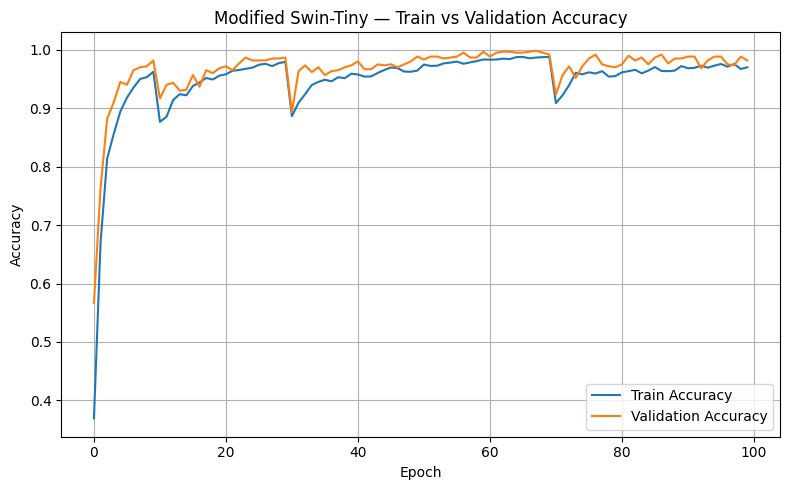

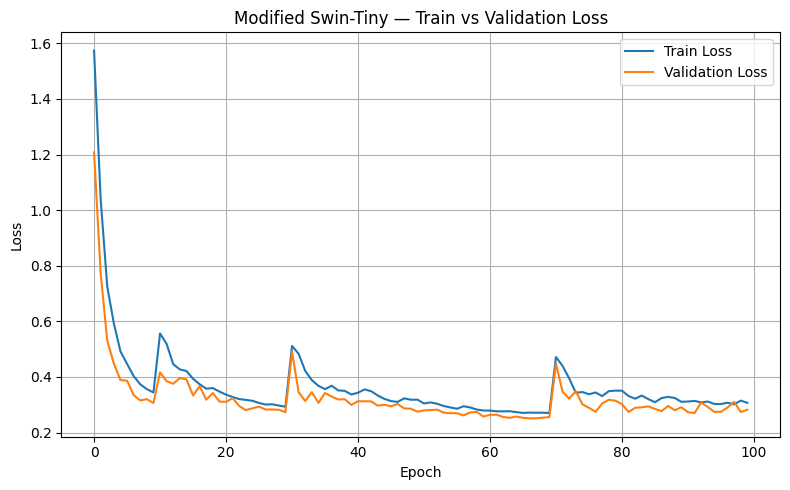


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 43.97it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6967    0.8500    0.7658       100
        fear     0.8505    0.9100    0.8792       100
         joy     0.8596    0.9800    0.9159       100
     natural     0.8585    0.9100    0.8835       100
     sadness     0.7241    0.4200    0.5316       100
    surprise     0.8495    0.7900    0.8187       100

    accuracy                         0.8100       600
   macro avg     0.8065    0.8100    0.7991       600
weighted avg     0.8065    0.8100    0.7991       600



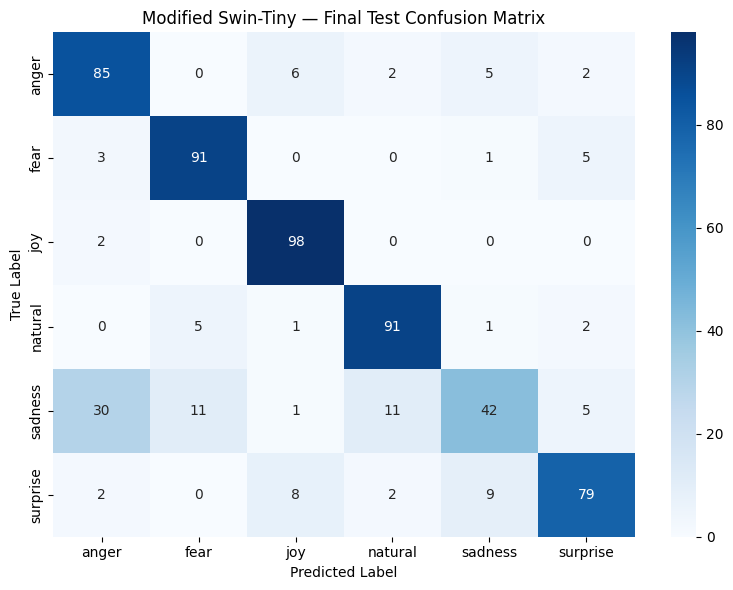


Modified Swin-Tiny Final Result:


,model,batch_size,modification,best_train_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,modified_swin_tiny_mbconv_cbam,16,"Stage2=MBConv, Stage3=Swin+CBAM",0.9877,0.81,0.8065,0.81,0.7991,0.8065,0.81,0.7991



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/modified_swin_tiny_mbconv_cbam


In [ ]:
# ============================================================
# Modified Swin-Tiny
# Changes:
#   Stage 2 (Block index 1) → Replaced with EfficientNet MBConv Block
#   Stage 3 (Block index 2) → Added CBAM Attention after Swin Block
#   Stage 1 and Stage 4     → Original Swin Blocks unchanged
# Training:
#   No backbone freezing — full model trains from epoch 1
#   Single optimizer for all parameters
#   Epochs: 100
# ============================================================

import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# RESULTS DIR
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)
print("RESULTS_DIR_B16:", RESULTS_DIR_B16)


# ============================================================
# Datasets and Loaders
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Dataloaders ready.")


# ============================================================
# CBAM Module (added after Stage 3)
# ============================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc       = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        B, C, H, W = x.shape
        avg_out    = self.fc(self.avg_pool(x).view(B, C))
        max_out    = self.fc(self.max_pool(x).view(B, C))
        out        = self.sigmoid(avg_out + max_out).view(B, C, 1, 1)
        return x * out


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=kernel_size,
                                 padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out    = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x,  dim=1, keepdim=True)
        out        = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * out


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


# ============================================================
# EfficientNet MBConv Block (replaces Stage 2)
# ============================================================

class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super(SqueezeExcitation, self).__init__()
        reduced = max(1, in_channels // reduction)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_channels, reduced, bias=False),
            nn.SiLU(),
            nn.Linear(reduced, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x).unsqueeze(-1).unsqueeze(-1)
        return x * scale


class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio=6, stride=1):
        super(MBConvBlock, self).__init__()
        hidden_dim   = in_channels * expand_ratio
        self.use_res = (stride == 1 and in_channels == out_channels)
        self.block   = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride,
                      padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(),
            SqueezeExcitation(hidden_dim),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        if self.use_res:
            return x + self.block(x)
        return self.block(x)


# ============================================================
# Patch Merge layer
# ============================================================

class PatchMerge(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(PatchMerge, self).__init__()
        self.merge = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=2, stride=2, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        return self.merge(x)


# ============================================================
# Full Modified Swin-Tiny Model
# Stage 1 (96ch)  → original Swin unchanged
# Stage 2 (192ch) → REPLACED with MBConvBlock
# Stage 3 (384ch) → original Swin + CBAM added after
# Stage 4 (768ch) → original Swin unchanged
# ============================================================

class ModifiedSwinTiny(nn.Module):
    def __init__(self, num_classes):
        super(ModifiedSwinTiny, self).__init__()

        self.swin_backbone = timm.create_model(
            "swin_tiny_patch4_window7_224",
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )

        self.patch_merge_1_2 = PatchMerge(in_channels=96,  out_channels=192)

        self.stage2_mbconv   = nn.Sequential(
            MBConvBlock(in_channels=192, out_channels=192, expand_ratio=6, stride=1),
            MBConvBlock(in_channels=192, out_channels=192, expand_ratio=6, stride=1)
        )

        self.stage3_cbam     = CBAM(in_channels=384, reduction=16, kernel_size=7)

        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier      = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        stage_outputs = self.swin_backbone(x)

        # Stage 1 — unchanged
        s1     = stage_outputs[0]
        s1_chw = s1.permute(0, 3, 1, 2).contiguous()        # [B, 96, 56, 56]

        # Stage 2 — MBConv instead of Swin block
        s2_in  = self.patch_merge_1_2(s1_chw)               # [B, 192, 28, 28]
        s2     = self.stage2_mbconv(s2_in)                   # [B, 192, 28, 28]

        # Stage 3 — Swin output + CBAM
        s3_swin = stage_outputs[2]                           # [B, 14, 14, 384]
        s3_chw  = s3_swin.permute(0, 3, 1, 2).contiguous() # [B, 384, 14, 14]
        s3      = self.stage3_cbam(s3_chw)                  # [B, 384, 14, 14]

        # Stage 4 — unchanged
        s4     = stage_outputs[3]                            # [B, 7, 7, 768]
        s4_chw = s4.permute(0, 3, 1, 2).contiguous()       # [B, 768, 7, 7]

        out    = self.global_avg_pool(s4_chw)               # [B, 768, 1, 1]
        out    = self.classifier(out)                        # [B, num_classes]

        return out


# ============================================================
# Training Function
# ============================================================

def train_modified_swin(epochs=100, lr=LR, model_folder_name="modified_swin_tiny_mbconv_cbam"):
    print("\n" + "=" * 90)
    print("Training Modified Swin-Tiny")
    print("  Stage 2 → Replaced with EfficientNet MBConv Block")
    print("  Stage 3 → Swin Block + CBAM Attention added")
    print("  No backbone freezing — full model trains from epoch 1")
    print("  Epochs: 100 | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = ModifiedSwinTiny(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels  = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs         = model(images)
            loss            = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("Modified Swin-Tiny — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("Modified Swin-Tiny — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("Modified Swin-Tiny — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              16,
        "modification":            "Stage2=MBConv, Stage3=Swin+CBAM",
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "modified_swin_result_summary.csv"), index=False)
    print("\nModified Swin-Tiny Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model


# ============================================================
# Run
# ============================================================

modified_swin_result, modified_swin_model = train_modified_swin(
    epochs=100,
    lr=LR,
    model_folder_name="modified_swin_tiny_mbconv_cbam"
)

In [ ]:
print(f"Total Parameters: {sum(p.numel() for p in modified_swin_model.parameters()):,}")
print(f"Total (Millions): {sum(p.numel() for p in modified_swin_model.parameters()) / 1e6:.2f}M")

NameError: name 'modified_swin_model' is not defined

#modified EfficientNet-B0

RESULTS_DIR_B16: /content/drive/MyDrive/autismemotion_project2/results/batch_16
Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images used for training: 3000
Final testing images: 600
Dataloaders ready.

Training Fixed Modified EfficientNet-B0
  MHA added after 24-channel stage
  Reduced block added: 24ch → 20ch
  Channel adapter: 20ch → 40ch
  CBAM added after 80-channel stage
  Original 112-channel block skipped, adapter: 80ch → 112ch
  No backbone freezing — full model trains from epoch 1
  Epochs: 100 | Batch Size: 16


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Number of EfficientNet-B0 block groups found: 7


Epoch 1/100 Validation: 100%|██████████| 38/38 [00:00<00:00, 44.83it/s]


Epoch 1/100 | Train Loss: 1.7751 | Train Acc: 0.2090 | Val Loss: 1.7536 | Val Acc: 0.2533 | LR: 0.00009758 | Time: 11.3s


...

Epoch 98/100 | Train Loss: 0.3241 | Train Acc: 0.9633 | Val Loss: 0.3003 | Val Acc: 0.9783 | LR: 0.00007297 | Time: 9.7s


Epoch 99/100 Validation: 100%|██████████| 38/38 [00:00<00:00, 40.62it/s]


Epoch 99/100 | Train Loss: 0.3150 | Train Acc: 0.9693 | Val Loss: 0.3124 | Val Acc: 0.9700 | LR: 0.00007122 | Time: 9.7s


Epoch 100/100 Validation: 100%|██████████| 38/38 [00:00<00:00, 44.43it/s]


Epoch 100/100 | Train Loss: 0.3144 | Train Acc: 0.9710 | Val Loss: 0.2893 | Val Acc: 0.9817 | LR: 0.00006944 | Time: 9.6s


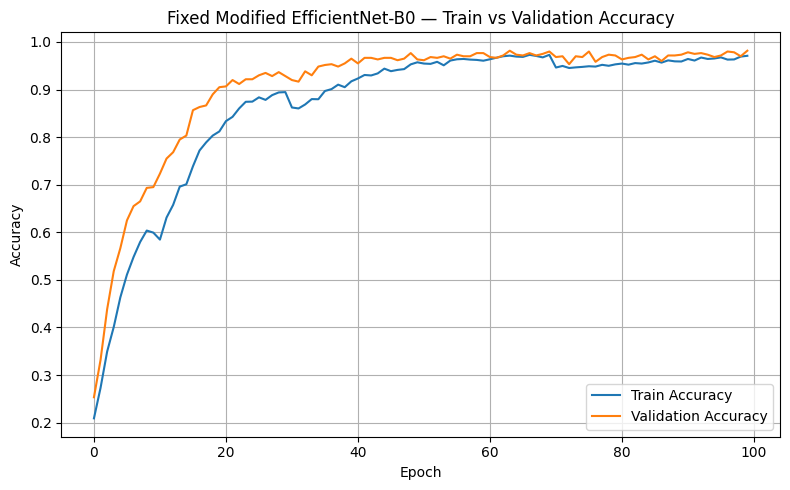

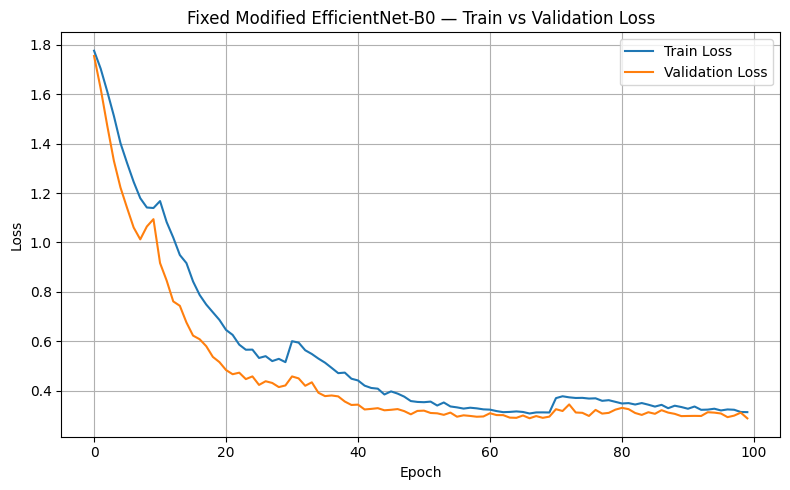


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 39.31it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7010    0.6800    0.6904       100
        fear     0.7895    0.9000    0.8411       100
         joy     0.6911    0.8500    0.7623       100
     natural     0.7843    0.8000    0.7921       100
     sadness     0.5672    0.3800    0.4551       100
    surprise     0.7010    0.6800    0.6904       100

    accuracy                         0.7150       600
   macro avg     0.7057    0.7150    0.7052       600
weighted avg     0.7057    0.7150    0.7052       600



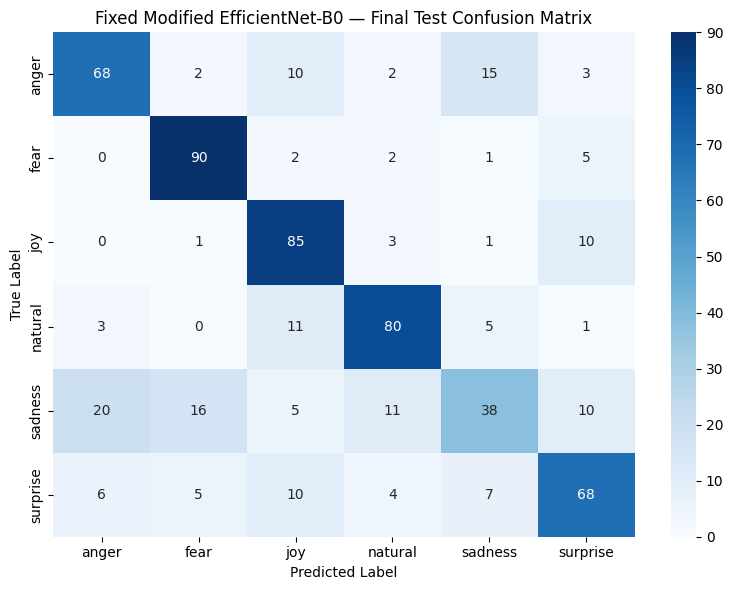


Fixed Modified EfficientNet-B0 Final Result:


,model,batch_size,modification,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,modified_efficientnet_b0_fixed_final,16,MHA + ReducedBlock + CBAM + Skip112Block + Ada...,0.9817,0.715,0.7057,0.715,0.7052,0.7057,0.715,0.7052



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/modified_efficientnet_b0_fixed_final


In [ ]:
# ============================================================
# Modified EfficientNet-B0
# Fixes:
#   1. timm EfficientNet-B0 has blocks[0] to blocks[6]
#   2. backbone.act2 handled safely
#   3. Channel mismatch fixed using adapters
# Training:
#   No backbone freezing — full model trains from epoch 1
#   Single optimizer for all parameters
#   Epochs: 100
# ============================================================

import os
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# RESULTS DIR
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)
print("RESULTS_DIR_B16:", RESULTS_DIR_B16)


# ============================================================
# Dataset and Dataloader
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images used for training:", len(combined_train_dataset))
print("Final testing images:", len(test_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Dataloaders ready.")


# ============================================================
# CBAM Module
# ============================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        reduced_channels = max(1, in_channels // reduction)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, reduced_channels, bias=False),
            nn.ReLU(),
            nn.Linear(reduced_channels, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, h, w = x.shape
        avg_out    = self.fc(self.avg_pool(x).view(b, c))
        max_out    = self.fc(self.max_pool(x).view(b, c))
        attention  = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attention


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out    = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x,  dim=1, keepdim=True)
        attention  = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attention


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


# ============================================================
# Spatial Multi-Head Attention
# ============================================================

class SpatialMultiHeadAttention(nn.Module):
    def __init__(self, in_channels, num_heads=4, dropout=0.1):
        super(SpatialMultiHeadAttention, self).__init__()
        self.norm    = nn.LayerNorm(in_channels)
        self.mha     = nn.MultiheadAttention(embed_dim=in_channels, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.proj    = nn.Linear(in_channels, in_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        b, c, h, w  = x.shape
        tokens      = x.flatten(2).transpose(1, 2)
        tokens_norm = self.norm(tokens)
        attn_out, _ = self.mha(tokens_norm, tokens_norm, tokens_norm)
        attn_out    = self.proj(attn_out)
        attn_out    = self.dropout(attn_out)
        tokens      = tokens + attn_out
        x           = tokens.transpose(1, 2).reshape(b, c, h, w)
        return x


# ============================================================
# Squeeze Excitation
# ============================================================

class SqueezeExcitation(nn.Module):
    def __init__(self, in_channels, reduction=4):
        super(SqueezeExcitation, self).__init__()
        reduced_channels = max(1, in_channels // reduction)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(in_channels, reduced_channels, bias=False),
            nn.SiLU(),
            nn.Linear(reduced_channels, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.se(x).unsqueeze(-1).unsqueeze(-1)
        return x * scale


# ============================================================
# Reduced MBConv Block
# ============================================================

class ReducedMBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expand_ratio=6, stride=1):
        super(ReducedMBConvBlock, self).__init__()
        hidden_dim        = in_channels * expand_ratio
        self.use_residual = stride == 1 and in_channels == out_channels
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, hidden_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(),
            nn.Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.SiLU(),
            SqueezeExcitation(hidden_dim),
            nn.Conv2d(hidden_dim, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)


# ============================================================
# Channel Adapter
# ============================================================

class ChannelAdapter(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ChannelAdapter, self).__init__()
        self.adapter = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.SiLU()
        )

    def forward(self, x):
        return self.adapter(x)


# ============================================================
# Modified EfficientNet-B0
# ============================================================

class ModifiedEfficientNetB0(nn.Module):
    def __init__(self, num_classes):
        super(ModifiedEfficientNetB0, self).__init__()

        backbone = timm.create_model("efficientnet_b0", pretrained=True, features_only=False)
        blocks   = list(backbone.blocks.children())

        print("Number of EfficientNet-B0 block groups found:", len(blocks))
        if len(blocks) != 7:
            raise ValueError(f"Expected 7 EfficientNet-B0 block groups from timm, but found {len(blocks)}.")

        # Stem
        self.conv_stem = backbone.conv_stem
        self.bn1       = backbone.bn1
        self.act1      = backbone.act1 if hasattr(backbone, "act1") else nn.SiLU(inplace=True)

        # Original blocks[0] → 16ch, blocks[1] → 24ch
        self.block0 = blocks[0]
        self.block1 = blocks[1]

        # MHA after 24ch block
        self.mha_block1 = SpatialMultiHeadAttention(in_channels=24, num_heads=4, dropout=0.1)

        # Reduced block: 24ch → 20ch (replaces original 40ch block)
        self.block2_reduced   = ReducedMBConvBlock(in_channels=24, out_channels=20, expand_ratio=6, stride=2)

        # Adapter: 20ch → 40ch (next original block expects 40ch input)
        self.adapter_20_to_40 = ChannelAdapter(in_channels=20, out_channels=40)

        # Original 80ch block
        self.block3 = blocks[3]

        # CBAM after 80ch block
        self.cbam_block3 = CBAM(in_channels=80, reduction=16, kernel_size=7)

        # Skip original 112ch block — adapter 80ch → 112ch
        self.adapter_80_to_112 = ChannelAdapter(in_channels=80, out_channels=112)

        # Remaining original blocks
        self.block5 = blocks[5]
        self.block6 = blocks[6]

        # Head
        self.conv_head  = backbone.conv_head
        self.bn2        = backbone.bn2
        self.act2       = backbone.act2 if hasattr(backbone, "act2") else nn.SiLU(inplace=True)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(1280, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.act1(self.bn1(self.conv_stem(x)))
        x = self.block0(x)
        x = self.block1(x)
        x = self.mha_block1(x)
        x = self.block2_reduced(x)
        x = self.adapter_20_to_40(x)
        x = self.block3(x)
        x = self.cbam_block3(x)
        x = self.adapter_80_to_112(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.act2(self.bn2(self.conv_head(x)))
        x = self.global_pool(x)
        x = self.classifier(x)
        return x


# ============================================================
# Training Function
# ============================================================

def train_modified_efficientnet(epochs=100, lr=LR, model_folder_name="modified_efficientnet_b0_fixed_final"):
    print("\n" + "=" * 90)
    print("Training Fixed Modified EfficientNet-B0")
    print("  MHA added after 24-channel stage")
    print("  Reduced block added: 24ch → 20ch")
    print("  Channel adapter: 20ch → 40ch")
    print("  CBAM added after 80-channel stage")
    print("  Original 112-channel block skipped, adapter: 80ch → 112ch")
    print("  No backbone freezing — full model trains from epoch 1")
    print("  Epochs: 100 | Batch Size: 16")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = ModifiedEfficientNetB0(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs        = model(images)
            loss           = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("Fixed Modified EfficientNet-B0 — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("Fixed Modified EfficientNet-B0 — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("Fixed Modified EfficientNet-B0 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              BATCH_SIZE,
        "modification":            "MHA + ReducedBlock + CBAM + Skip112Block + Adapters",
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "modified_efficientnet_b0_fixed_final_result_summary.csv"), index=False)
    print("\nFixed Modified EfficientNet-B0 Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model


# ============================================================
# Run
# ============================================================

modified_efficientnet_result, modified_efficientnet_model = train_modified_efficientnet(
    epochs=100,
    lr=LR,
    model_folder_name="modified_efficientnet_b0_fixed_final"
)

# EfficientNetV2-B2

Using augmented dataset.
Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images used for training: 3000
Final testing images: 600

Training EfficientNetV2-B2
Using model: tf_efficientnetv2_b2


model.safetensors:   0%|          | 0.00/40.8M [00:00<?, ?B/s]

Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 46.27it/s]


Epoch 1/30 | Train Loss: 1.6320 | Train Acc: 0.4543 | Val Loss: 0.7661 | Val Acc: 0.7883 | LR: 0.00009055 | Time: 5.1s


Epoch 2/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 49.27it/s]


...

Epoch 28/30 | Train Loss: 0.2973 | Train Acc: 0.9843 | Val Loss: 0.2828 | Val Acc: 0.9917 | LR: 0.00002803 | Time: 5.1s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 44.35it/s]


Epoch 29/30 | Train Loss: 0.2933 | Train Acc: 0.9850 | Val Loss: 0.2799 | Val Acc: 0.9900 | LR: 0.00002140 | Time: 5.2s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 46.85it/s]


Epoch 30/30 | Train Loss: 0.2923 | Train Acc: 0.9870 | Val Loss: 0.2739 | Val Acc: 0.9917 | LR: 0.00001550 | Time: 4.8s


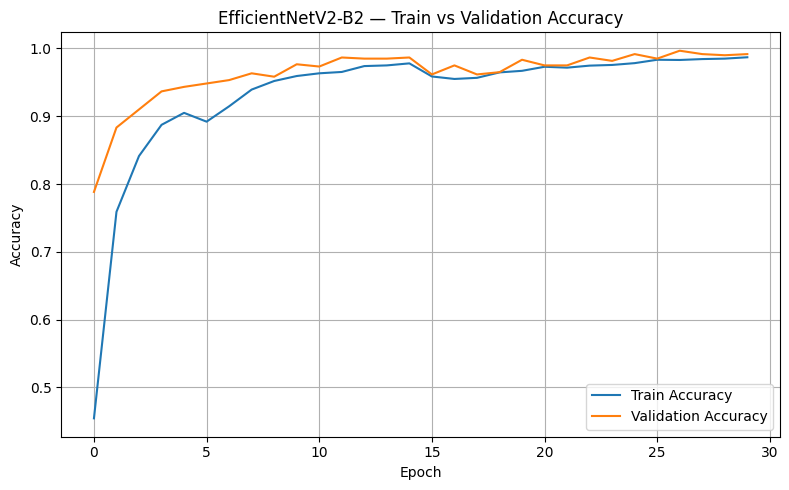

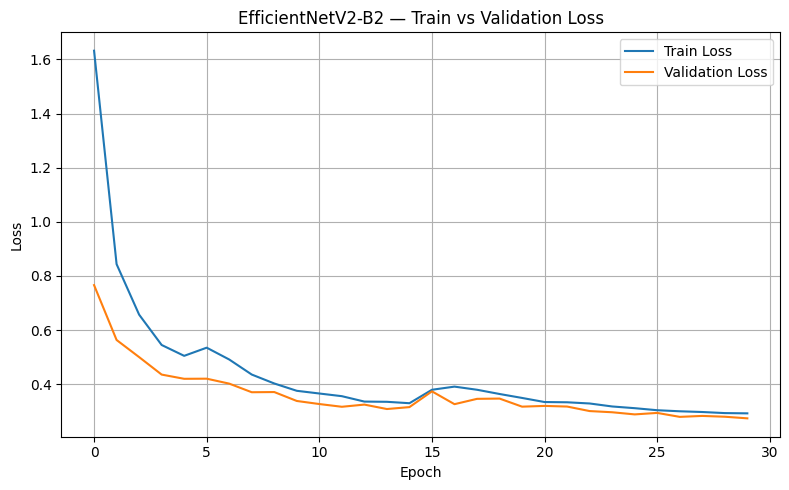


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 45.61it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.7094    0.8300    0.7650       100
        fear     0.8230    0.9300    0.8732       100
         joy     0.8667    0.9100    0.8878       100
     natural     0.8230    0.9300    0.8732       100
     sadness     0.7115    0.3700    0.4868       100
    surprise     0.8400    0.8400    0.8400       100

    accuracy                         0.8017       600
   macro avg     0.7956    0.8017    0.7877       600
weighted avg     0.7956    0.8017    0.7877       600



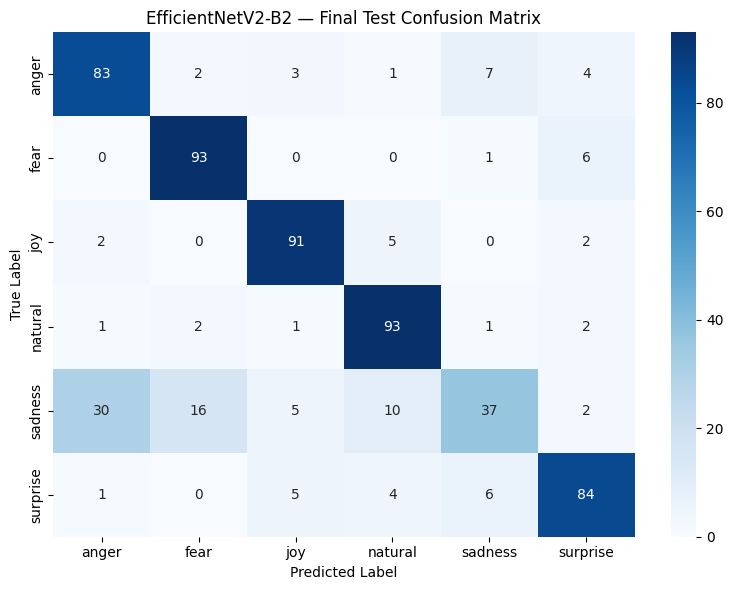


EfficientNetV2-B2 Final Result:


,model,batch_size,best_validation_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,efficientnet_v2_b2,16,0.9967,0.8017,0.7956,0.8017,0.7877,0.7956,0.8017,0.7877



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/efficientnet_v2_b2


In [ ]:
# ============================================================
# EfficientNetV2-B2 Model Cell
# Train: Train + Validation set
# Final Test: Test set only
# ============================================================

import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# Safe Settings
# ============================================================

if "IMG_SIZE" not in globals():
    IMG_SIZE = 224

if "BATCH_SIZE" not in globals():
    BATCH_SIZE = 16

if "NUM_WORKERS" not in globals():
    NUM_WORKERS = 2

if "EPOCHS" not in globals():
    EPOCHS = 30

if "LR" not in globals():
    LR = 1e-4

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "RESULTS_DIR_B16" not in globals():
    RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
    os.makedirs(RESULTS_DIR_B16, exist_ok=True)

# ============================================================
# Transform
# ============================================================

if "transform" not in globals():
    transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.95, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

# ============================================================
# Dataset Paths
# It will use augmented dataset if available.
# Otherwise it will use split dataset.
# ============================================================

if os.path.exists(AUG_TRAIN_DIR) and os.path.exists(AUG_VAL_DIR) and os.path.exists(AUG_TEST_DIR):
    TRAIN_DIR = AUG_TRAIN_DIR
    VAL_DIR   = AUG_VAL_DIR
    TEST_DIR  = AUG_TEST_DIR
    print("Using augmented dataset.")
else:
    TRAIN_DIR = SPLIT_TRAIN_DIR
    VAL_DIR   = SPLIT_VAL_DIR
    TEST_DIR  = SPLIT_TEST_DIR
    print("Using split dataset.")

# ============================================================
# Datasets and Loaders
# ============================================================

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=transform)

if train_dataset.classes != val_dataset.classes:
    raise ValueError("Train and validation class names do not match!")

if train_dataset.classes != test_dataset.classes:
    raise ValueError("Train and test class names do not match!")

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])

print("Total training images used for training:", len(combined_train_dataset))
print("Final testing images:", len(test_dataset))

train_loader = DataLoader(
    combined_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# ============================================================
# Build EfficientNetV2-B2
# ============================================================

def build_efficientnet_v2_b2(num_classes):
    model_candidates = [
        "tf_efficientnetv2_b2.in21k_ft_in1k",
        "tf_efficientnetv2_b2",
        "efficientnetv2_b2"
    ]

    available_models = timm.list_models()

    for model_name in model_candidates:
        if model_name in available_models:
            try:
                print("Using model:", model_name)
                return timm.create_model(
                    model_name,
                    pretrained=True,
                    num_classes=num_classes
                )
            except Exception as e:
                print(f"Pretrained loading failed for {model_name}. Trying without pretrained weights.")
                print("Reason:", e)
                return timm.create_model(
                    model_name,
                    pretrained=False,
                    num_classes=num_classes
                )

    raise ValueError(
        "EfficientNetV2-B2 model was not found in your timm version. "
        "Run: !pip install -U timm"
    )

# ============================================================
# Train EfficientNetV2-B2
# ============================================================

def train_efficientnet_v2_b2(epochs=EPOCHS, lr=LR, model_folder_name="efficientnet_v2_b2"):
    print("\n" + "=" * 90)
    print("Training EfficientNetV2-B2")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model = build_efficientnet_v2_b2(num_classes).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=5,
        T_mult=2,
        eta_min=1e-6
    )

    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            _, predictions = torch.max(outputs, 1)

            train_loss_sum += loss.item() * images.size(0)
            train_correct += torch.sum(predictions == labels).item()
            train_total += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total

        model.eval()
        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                _, predictions = torch.max(outputs, 1)

                val_loss_sum += loss.item() * images.size(0)
                val_correct += torch.sum(predictions == labels).item()
                val_total += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time() - start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title("EfficientNetV2-B2 — Train vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png"))
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title("EfficientNetV2-B2 — Train vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png"))
    plt.show()

    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()

    test_y_true = []
    test_y_pred = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)

            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(
        classification_report(
            test_y_true,
            test_y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(test_y_true, test_y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.title("EfficientNetV2-B2 — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png"))
    plt.show()

    report = classification_report(
        test_y_true,
        test_y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report).transpose().to_csv(
        os.path.join(model_output_dir, "test_classification_report.csv")
    )

    pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    ).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model": model_folder_name,
        "batch_size": BATCH_SIZE,
        "best_validation_accuracy": round(best_val_acc, 4),
        "final_test_accuracy": round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision": round(report["macro avg"]["precision"], 4),
        "test_macro_recall": round(report["macro avg"]["recall"], 4),
        "test_macro_f1": round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall": round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1": round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])

    result_df.to_csv(
        os.path.join(model_output_dir, "efficientnet_v2_b2_result_summary.csv"),
        index=False
    )

    print("\nEfficientNetV2-B2 Final Result:")
    display(result_df)

    print("\nSaved files inside:", model_output_dir)

    return result, model

# ============================================================
# Run EfficientNetV2-B2
# ============================================================

efficientnet_v2_b2_result, efficientnet_v2_b2_model = train_efficientnet_v2_b2(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="efficientnet_v2_b2"
)

# EfficientNetV2-B2 with CBAM

In [ ]:
# Run this diagnostic cell first to check available stages
import timm

model_check = timm.create_model(
    "tf_efficientnetv2_b2",
    pretrained=True,
    features_only=True
)

print("Available stages    :", len(model_check.feature_info))
print("Stage channels      :", model_check.feature_info.channels())
print("Stage reductions    :", model_check.feature_info.reduction())
del model_check

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/40.8M [00:00<?, ?B/s]

Available stages    : 5
Stage channels      : [16, 32, 56, 120, 208]
Stage reductions    : [2, 4, 8, 16, 32]


RESULTS_DIR_B16: /content/drive/MyDrive/autismemotion_project2/results/batch_16
Classes          : ['anger', 'fear', 'joy', 'natural', 'sadness', 'surprise']
Number of classes: 6
Train images     : 2400
Validation images: 600
Test images      : 600
Total training images (train + val): 3000
Dataloaders ready.

Training EfficientNetV2-B2 + CBAM
  No backbone freezing — full model trains from epoch 1
  CBAM after Stage 2 (56ch), Stage 3 (120ch), Stage 4 (208ch)
  Batch Size: 16


Epoch 1/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 47.25it/s]


Epoch 1/30 | Train Loss: 1.6192 | Train Acc: 0.3857 | Val Loss: 1.1032 | Val Acc: 0.6750 | LR: 0.00009055 | Time: 4.8s


Epoch 2/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 49.31it/s]


Epoch 2/30 | Train Loss: 0.9175 | Train Acc: 0.7300 | Val Loss: 0.5396 | Val Acc: 0.8867 | LR: 0.00006580 | Time: 4.4s


...

Epoch 28/30 | Train Loss: 0.2928 | Train Acc: 0.9813 | Val Loss: 0.2712 | Val Acc: 0.9883 | LR: 0.00002803 | Time: 4.5s


Epoch 29/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 42.54it/s]


Epoch 29/30 | Train Loss: 0.2903 | Train Acc: 0.9817 | Val Loss: 0.2675 | Val Acc: 0.9883 | LR: 0.00002140 | Time: 4.7s


Epoch 30/30 Validation: 100%|██████████| 38/38 [00:00<00:00, 46.57it/s]


Epoch 30/30 | Train Loss: 0.2833 | Train Acc: 0.9857 | Val Loss: 0.2632 | Val Acc: 0.9950 | LR: 0.00001550 | Time: 4.7s


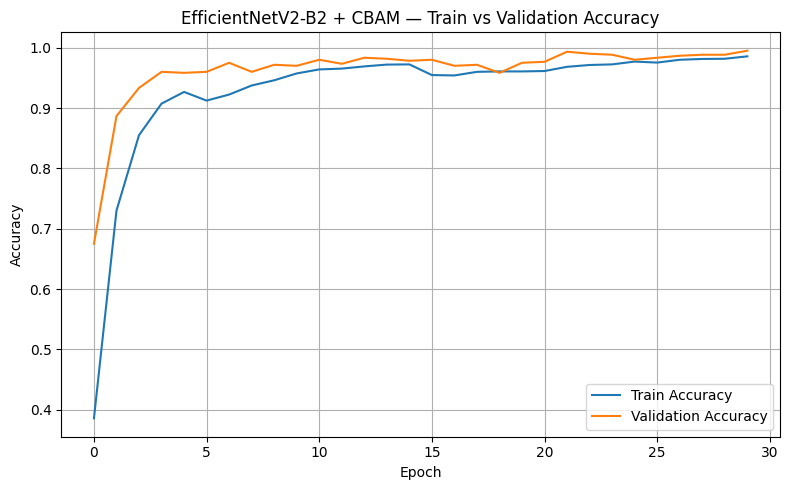

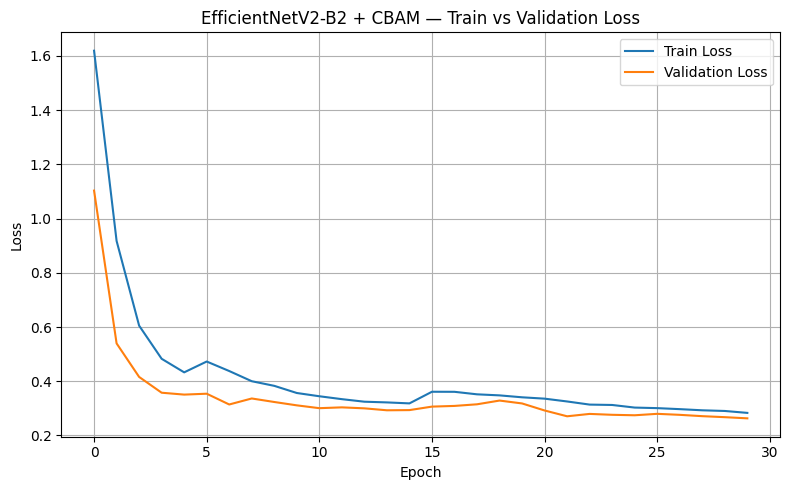


Final Testing on Test Set Only


Final Testing: 100%|██████████| 38/38 [00:00<00:00, 47.05it/s]



Final Test Classification Report:
              precision    recall  f1-score   support

       anger     0.6870    0.7900    0.7349       100
        fear     0.8198    0.9100    0.8626       100
         joy     0.9293    0.9200    0.9246       100
     natural     0.8148    0.8800    0.8462       100
     sadness     0.6441    0.3800    0.4780       100
    surprise     0.7407    0.8000    0.7692       100

    accuracy                         0.7800       600
   macro avg     0.7726    0.7800    0.7692       600
weighted avg     0.7726    0.7800    0.7692       600



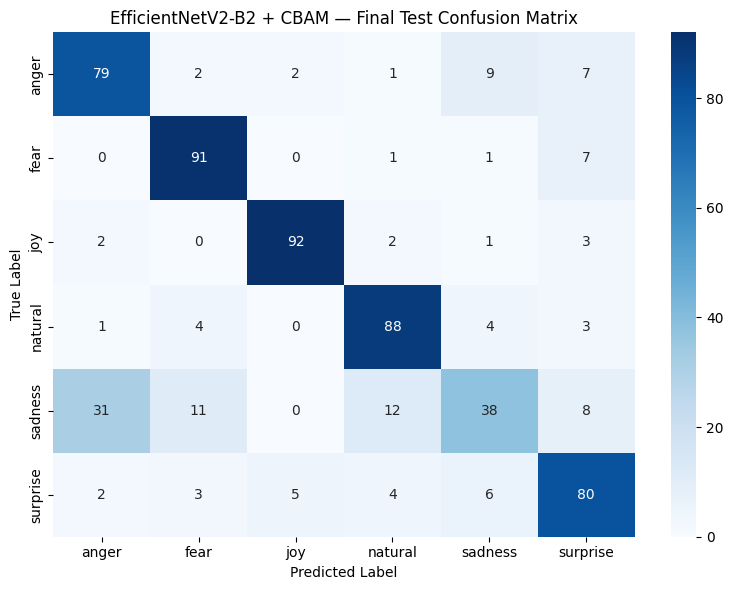


EfficientNetV2-B2 + CBAM Final Result:


,model,batch_size,modification,best_val_accuracy,final_test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1
0,efficientnetv2_b2_cbam_simple,16,CBAM after Stage2(56ch) Stage3(120ch) Stage4(2...,0.995,0.78,0.7726,0.78,0.7692,0.7726,0.78,0.7692



Saved files inside: /content/drive/MyDrive/autismemotion_project2/results/batch_16/efficientnetv2_b2_cbam_simple


In [ ]:
# ============================================================
# EfficientNetV2-B2 + CBAM
# No backbone freezing — full model trains from start
# CBAM after Stage 2 (56ch), Stage 3 (120ch), Stage 4 (208ch)
# Self-contained — runs after cells 1-5 only
# ============================================================

import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# RESULTS DIR
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)
print("RESULTS_DIR_B16:", RESULTS_DIR_B16)


# ============================================================
# Datasets and Loaders
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(
    combined_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Dataloaders ready.")


# ============================================================
# CBAM Module
# ============================================================

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc       = nn.Sequential(
            nn.Linear(in_channels, max(1, in_channels // reduction), bias=False),
            nn.ReLU(),
            nn.Linear(max(1, in_channels // reduction), in_channels, bias=False)
        )
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        B, C, H, W = x.shape
        avg_out    = self.fc(self.avg_pool(x).view(B, C))
        max_out    = self.fc(self.max_pool(x).view(B, C))
        return x * self.sigmoid(avg_out + max_out).view(B, C, 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv    = nn.Conv2d(
            2, 1,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out    = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x,  dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x


# ============================================================
# EfficientNetV2-B2 + CBAM Model
# Stage channels confirmed: [16, 32, 56, 120, 208]
# ============================================================

class EfficientNetV2B2CBAM(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetV2B2CBAM, self).__init__()

        self.backbone = timm.create_model(
            "tf_efficientnetv2_b2",
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4)
        )

        # CBAM for Stage 2, 3, 4
        self.cbam_s2 = CBAM(in_channels=56,  reduction=8,  kernel_size=7)
        self.cbam_s3 = CBAM(in_channels=120, reduction=16, kernel_size=7)
        self.cbam_s4 = CBAM(in_channels=208, reduction=16, kernel_size=7)

        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(208),
            nn.Linear(208, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        stages = self.backbone(x)

        # Stage 0, 1 unchanged
        s0 = stages[0]
        s1 = stages[1]

        # Stage 2, 3, 4 with CBAM
        s2  = self.cbam_s2(stages[2])
        s3  = self.cbam_s3(stages[3])
        s4  = self.cbam_s4(stages[4])

        out = self.global_avg_pool(s4)
        out = self.classifier(out)

        return out


# ============================================================
# Training Function
# ============================================================

def train_efficientnetv2b2_cbam(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="efficientnetv2_b2_cbam_simple"
):
    print("\n" + "=" * 90)
    print("Training EfficientNetV2-B2 + CBAM")
    print("  No backbone freezing — full model trains from epoch 1")
    print("  CBAM after Stage 2 (56ch), Stage 3 (120ch), Stage 4 (208ch)")
    print("  Batch Size:", BATCH_SIZE)
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = EfficientNetV2B2CBAM(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=5, T_mult=2, eta_min=1e-6
    )

    best_val_acc       = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()

        # Training
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs} Training"
        ):
            images, labels  = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs         = model(images)
            loss            = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        # Validation
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(
                val_loader,
                desc=f"Epoch {epoch+1}/{epochs} Validation"
            ):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc       = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(
                model.state_dict(),
                os.path.join(model_output_dir, "best_model.pth")
            )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(
        os.path.join(model_output_dir, "training_history.csv"), index=False
    )

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("EfficientNetV2-B2 + CBAM — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("EfficientNetV2-B2 + CBAM — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # Final test
    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(
        test_y_true, test_y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.title("EfficientNetV2-B2 + CBAM — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(
        test_y_true, test_y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report).transpose().to_csv(
        os.path.join(model_output_dir, "test_classification_report.csv")
    )
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(
        os.path.join(model_output_dir, "test_confusion_matrix.csv")
    )

    result = {
        "model":                   model_folder_name,
        "batch_size":              BATCH_SIZE,
        "modification":            "CBAM after Stage2(56ch) Stage3(120ch) Stage4(208ch)",
        "best_val_accuracy":       round(best_val_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(
        os.path.join(model_output_dir, "efficientnetv2b2_cbam_result_summary.csv"),
        index=False
    )

    print("\nEfficientNetV2-B2 + CBAM Final Result:")
    display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model


# ============================================================
# Run
# ============================================================

efficientnetv2b2_cbam_result, efficientnetv2b2_cbam_model = train_efficientnetv2b2_cbam(
    epochs=EPOCHS,
    lr=LR,
    model_folder_name="efficientnetv2_b2_cbam_simple"
)

maxvit


In [ ]:
# ============================================================
# Plain MaxViT-Large
# Model  : maxvit_large_tf_224 (pretrained)
# Train  : Train + Validation combined
# Test   : Test set only
# Epochs : 100
# No backbone freezing — full model trains from epoch 1
# ============================================================

import os
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ============================================================
# RESULTS DIR
# ============================================================

RESULTS_DIR_B16 = os.path.join(PROJECT_DIR, "results", "batch_16")
os.makedirs(RESULTS_DIR_B16, exist_ok=True)
print("RESULTS_DIR_B16:", RESULTS_DIR_B16)


# ============================================================
# Datasets and Loaders
# ============================================================

train_dataset = datasets.ImageFolder(AUG_TRAIN_DIR, transform=transform)
val_dataset   = datasets.ImageFolder(AUG_VAL_DIR,   transform=transform)
test_dataset  = datasets.ImageFolder(AUG_TEST_DIR,  transform=transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes          :", class_names)
print("Number of classes:", num_classes)
print("Train images     :", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images      :", len(test_dataset))

combined_train_dataset = ConcatDataset([train_dataset, val_dataset])
print("Total training images (train + val):", len(combined_train_dataset))

train_loader = DataLoader(combined_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,           batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print("Dataloaders ready.")


# ============================================================
# MaxViT-Large Model
# ============================================================

class MaxViTLarge(nn.Module):
    def __init__(self, num_classes):
        super(MaxViTLarge, self).__init__()

        self.backbone = timm.create_model(
            "maxvit_large_tf_224",
            pretrained=True,
            num_classes=0,        # remove default head
            global_pool=""        # disable global pool so we handle it
        )

        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)

        backbone_out_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(backbone_out_features),
            nn.Linear(backbone_out_features, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)          # [B, C, H, W]
        x = self.global_avg_pool(x)   # [B, C, 1, 1]
        x = self.classifier(x)        # [B, num_classes]
        return x


# ============================================================
# Training Function
# ============================================================

def train_maxvit_large(epochs=100, lr=LR, model_folder_name="maxvit_large_tf_224"):
    print("\n" + "=" * 90)
    print("Training Plain MaxViT-Large (maxvit_large_tf_224)")
    print("  Pretrained on ImageNet-21k")
    print("  No backbone freezing — full model trains from epoch 1")
    print(f"  Epochs: {epochs} | Batch Size: {BATCH_SIZE}")
    print("=" * 90)

    model_output_dir = os.path.join(RESULTS_DIR_B16, model_folder_name)
    os.makedirs(model_output_dir, exist_ok=True)

    model     = MaxViTLarge(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=10, T_mult=2, eta_min=1e-6
    )

    best_train_acc     = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())
    history            = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()

        # ── Train ──
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} Training"):
            images, labels  = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs         = model(images)
            loss            = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            _, predictions  = torch.max(outputs, 1)
            train_loss_sum += loss.item() * images.size(0)
            train_correct  += torch.sum(predictions == labels).item()
            train_total    += labels.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        # ── Validate ──
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} Validation"):
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                _, predictions = torch.max(outputs, 1)
                val_loss_sum  += loss.item() * images.size(0)
                val_correct   += torch.sum(predictions == labels).item()
                val_total     += labels.size(0)

        val_loss = val_loss_sum / val_total
        val_acc  = val_correct  / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if train_acc > best_train_acc:
            best_train_acc     = train_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), os.path.join(model_output_dir, "best_model.pth"))

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.8f} | "
            f"Time: {time.time()-start_time:.1f}s"
        )

    # ── Load best weights ──
    model.load_state_dict(best_model_weights)
    pd.DataFrame(history).to_csv(os.path.join(model_output_dir, "training_history.csv"), index=False)

    # ── Accuracy plot ──
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"],   label="Validation Accuracy")
    plt.title("MaxViT-Large — Train vs Validation Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "accuracy_curve.png")); plt.show()

    # ── Loss plot ──
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"],   label="Validation Loss")
    plt.title("MaxViT-Large — Train vs Validation Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "loss_curve.png")); plt.show()

    # ── Final Test ──
    print("\n" + "=" * 90)
    print("Final Testing on Test Set Only")
    print("=" * 90)

    model.eval()
    test_y_true, test_y_pred = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Final Testing"):
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predictions = torch.max(torch.softmax(outputs, dim=1), 1)
            test_y_true.extend(labels.cpu().numpy())
            test_y_pred.extend(predictions.cpu().numpy())

    print("\nFinal Test Classification Report:")
    print(classification_report(test_y_true, test_y_pred, target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(test_y_true, test_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.title("MaxViT-Large — Final Test Confusion Matrix")
    plt.xlabel("Predicted Label"); plt.ylabel("True Label"); plt.tight_layout()
    plt.savefig(os.path.join(model_output_dir, "confusion_matrix.png")); plt.show()

    report = classification_report(test_y_true, test_y_pred, target_names=class_names, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(os.path.join(model_output_dir, "test_classification_report.csv"))
    pd.DataFrame(cm, index=class_names, columns=class_names).to_csv(os.path.join(model_output_dir, "test_confusion_matrix.csv"))

    result = {
        "model":                   model_folder_name,
        "batch_size":              BATCH_SIZE,
        "modification":            "Plain MaxViT-Large pretrained",
        "best_train_accuracy":     round(best_train_acc, 4),
        "final_test_accuracy":     round(accuracy_score(test_y_true, test_y_pred), 4),
        "test_macro_precision":    round(report["macro avg"]["precision"], 4),
        "test_macro_recall":       round(report["macro avg"]["recall"], 4),
        "test_macro_f1":           round(report["macro avg"]["f1-score"], 4),
        "test_weighted_precision": round(report["weighted avg"]["precision"], 4),
        "test_weighted_recall":    round(report["weighted avg"]["recall"], 4),
        "test_weighted_f1":        round(report["weighted avg"]["f1-score"], 4)
    }

    result_df = pd.DataFrame([result])
    result_df.to_csv(os.path.join(model_output_dir, "maxvit_large_result_summary.csv"), index=False)
    print("\nMaxViT-Large Final Result:"); display(result_df)
    print("\nSaved files inside:", model_output_dir)
    return result, model


# ============================================================
# Run
# ============================================================

maxvit_large_result, maxvit_large_model = train_maxvit_large(
    epochs=100,
    lr=LR,
    model_folder_name="maxvit_large_tf_224"
)